# Variational GGMM: 같은 표본, 새로운 성분 수 학습

이 파일 하나만 있으면 실행할 수 있습니다. 기존 `GGMM_BIC.ipynb`는 수정하지 않습니다.
아래 코드 셀을 위에서부터 실행하세요. 기본 n=5,000, seed=20260912와 표본 추출 함수는 이전 실험과 같습니다.
새로 적합하고 실제 시간을 측정합니다. PKL·기존 적합값·파일 저장을 사용하지 않습니다.

**입력 X → 결정론적 초기화 → 변분 EM 공동 갱신 → 가중치로 유효 K 집계 → 표·그림·IAE·ISE**

- BIC로 K=1~10을 선택하는 루프가 없습니다. 상한 10의 한 모델을 학습합니다.
- 같은 상한의 quantile/lloyd 두 출발점을 비교하고 ELBO가 높은 결과를 택합니다. 참 밀도는 쓰지 않습니다.
- 초기 상한보다 많은 성분을 만들지는 않습니다. 기본 가중치 기준 0.005는 적합 후 판정 규칙입니다.
- **변분 EM 연구 구현**입니다. 가중치·소속·위치·일반화 정밀도는 변분분포, 형상 b는 점추정입니다.
  Amudala 논문의 테일러 근사를 그대로 재현하거나 모든 파라미터의 완전 베이지안 추론을 한 것은 아닙니다.
- 표시하는 밀도는 사후 파라미터를 대입한 **plug-in GGMM**입니다. 완전한 사후예측밀도와 다릅니다.
- 기본 실행 뒤 선택 실험의 스위치를 True로 바꾸면 상한·사전분포 변경마다 실제로 다시 적합합니다.
  특히 참 K=10에서 상한 5~15 비교는 11번 적합하므로 시간이 많이 걸릴 수 있습니다.
- IAE·ISE는 사후 평가에만 사용합니다. 참 K 복원, 수렴, VGM보다 빠른 실행은 보장하지 않습니다.

## 전달 전 확인한 결과

2026-09-28 로컬에서 기본 16개 코드 셀을 빈 작업 폴더에서 실행했습니다.
기본 n=5,000·seed=20260912에서 유효 K=10, IAE=0.0538642, ISE=0.000338802,
새 적합 시간 약 190.10초였고 외부 ELBO 종료 기준은 통과했습니다.
**참 K=3을 복원하지 못했으며, 변분 방식으로 바꾸기만 하면 성분이 줄어든다는 결과가 아닙니다.**
VGM은 같은 표본에서 유효 K=5, IAE=0.108209, ISE=0.00125026, 적합 약 0.69초였습니다.
초기화와 사전·종료 조건이 다른 단일 실행 비교이므로 일반적인 우열이나 속도 보장으로 해석하지 않습니다.
이 숫자는 개발 검증 기록입니다. 아래 셀은 매번 새로 적합하고 사용자의 실제 결과를 출력합니다.

## 무엇을 학습하는가?

X 전체의 평균·표준편차로 표준화한 좌표에서

\[
g(x\mid\mu,\tau,b)=\frac{b\tau^{1/b}}{2\Gamma(1/b)}
\exp[-\tau|x-\mu|^b],\qquad \tau=a^{-b}
\]

를 사용합니다. `q(v)`는 Beta, `q(z)`는 범주분포, `q(mu)`는 정규분포,
`q(tau)`는 Gamma(shape/rate)입니다. b는 양수인 점 파라미터입니다.

사전분포는 `v~Beta(1, concentration)`, `mu~Normal(0, mean_prior_sd**2)`,
`tau~Gamma(precision_prior_shape, precision_prior_rate)`입니다.
이는 표준화한 좌표에서 지정한 사전분포로, 원자료 단위에서 불변의 사전분포라는 뜻은 아닙니다.
특히 tau=a^(-b)이므로 Gamma 사전분포는 형상에 중립적이지 않습니다.
기존의 임의 척도 하한 대신 proper 사전분포를 사용하며, 이를 별도 민감도 셀에서 확인합니다.

최적화 목적은

\[
\mathcal L=\sum_{ik}r_{ik}\{\mathbb E\log\pi_k+
\mathbb E\log g(x_i\mid\mu_k,\tau_k,b_k)-\log r_{ik}\}
-\mathrm{KL}_v-\mathrm{KL}_\mu-\mathrm{KL}_\tau.
\]

정규분포의 절대 모멘트는 특수함수의 정확한 항등식으로 계산합니다.
소속을 고정하면 q(tau)는 Gamma(A0+Nk/b, B0+sum(r*E|x-mu|^b))로 갱신됩니다.
q(mu)의 평균·분산과 b는 이 Gamma 갱신을 대입한 ELBO를 수치적으로 높입니다.
표현할 수 없는 수치 제안은 거부 횟수로 공개합니다. 고정된 b 상한은 없습니다.

출력은 pi=E(pi), mu=E(mu), a=E(tau)^(-1/b)로 정의하고 원자료 단위로 복원합니다.
q(mu)의 표준편차는 **위치 추정의 불확실성**이고, GGD 자체의 표준편차와 다릅니다.
성분의 GGD 표준편차는 a,b에서 유도하며 별도로 추정하지 않습니다.

## 기존 질문과 새 셀의 대응

| 기존 질문 | 새 실험 |
|---|---|
| GGMM이 표본을 어떻게 설명하는가? | 추정식·성분 파라미터·참 밀도·VGM 비교 |
| 어떤 초기값을 채택했는가? | 같은 상한의 두 초기화와 최종 ELBO |
| K별 BIC/LL은 어떻게 변하는가? | 반복별 ELBO·plug-in LL·유효 K·가중치 경로 |
| 시간은 어디서 드는가? | 변분 갱신과 성분 수치 갱신의 시간 분리 |
| KDE와 어떻게 다른가? | 동일한 전체/3개 표본 KDE, 동일 seed |
| 3vs3·5vs5로 비교할 수 있는가? | 같은 상한에서 실제 유효 K 확인; 불일치를 숨기지 않음 |
| 상한2, 상한5~15라면? | 상한마다 독립 재적합; 이전 prefix 재사용 방식 불가 |
| 척도 하한을 없애면? | 새 모형에서는 척도 사전분포 민감도로 질문을 변경 |

## 원리의 근거와 이번 구현의 범위

- Blei & Jordan, *Variational inference for Dirichlet process mixtures*: https://www.cs.columbia.edu/~blei/papers/BleiJordan2006.pdf
- Amudala, 2020, *Variational techniques ... using generalized Gaussian distribution*, 2~3장: https://spectrum.library.concordia.ca/id/eprint/987537/1/Amudala_MASc_F2020.pdf
- Winkelbauer, *Moments and Absolute Moments of the Normal Distribution*: https://arxiv.org/abs/1209.4340
- 비교 모델: https://scikit-learn.org/stable/modules/generated/sklearn.mixture.BayesianGaussianMixture.html

GGMM 논문의 이름만 붙인 기존 BIC 코드가 아니라, 위에 명시한 모형의 ELBO를 유도한 별도 구현입니다.
무작위 초기화·다른 모델의 적합값·참 파라미터를 GGMM에 전달하지 않습니다.
현재 노트북은 밀도 추정 실험이며 CTGAN 생성기 연결·합성 품질 검증까지 완료한 것은 아닙니다.


In [1]:
# 준비 1: 변분 GGMM 모형 정의
# 이 셀은 추정기를 정의하며 아직 적합하지 않습니다.
"""Independent deterministic variational EM for a truncated DP GGD mixture.

q(v): Beta; q(z): categorical; q(mu): Normal; q(tau): Gamma (shape/rate).
b is a positive point estimate, tau=a**(-b). This is not an exact reproduction
of Amudala's Taylor-approximation algorithm or full Bayes over b.
Only X enters fit. Exported densities are normalized parameter plug-in GGMMs,
not the full posterior predictive density. No BIC search, cache, or file IO.
"""
from dataclasses import dataclass
from time import perf_counter
from typing import cast
import warnings
import numpy as np
from numpy.typing import ArrayLike
from scipy.special import gammaln, digamma, betaln, hyp1f1, logsumexp, xlogy
from scipy.optimize import minimize, brentq
from scipy.stats import gennorm


@dataclass(frozen=True)
class VGGMMConfig:
    max_components: int = 10
    concentration: float = .001
    active_threshold: float = .005
    max_iter: int = 300
    tol: float = 1e-5  # absolute ELBO improvement / n, not LL or gradient tolerance
    inner_max_iter: int = 30
    inner_ftol: float = 1e-8
    mean_prior_sd: float = 3.
    precision_prior_shape: float = 1.
    precision_prior_rate: float = .001
    starts: tuple = ('quantile', 'lloyd')
    fixed_shape: float | None = None


@dataclass(init=False)
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float).copy()
        self.means = np.asarray(means, dtype=float).copy()
        self.scales = np.asarray(scales, dtype=float).copy()
        self.shapes = np.asarray(shapes, dtype=float).copy()
        if (self.weights.ndim != 1 or not self.weights.size
                or any(getattr(self, k).shape != self.weights.shape
                       for k in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, k)).all()
                           for k in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights < 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        return self.scales * np.exp(.5*(gammaln(3/self.shapes)-gammaln(1/self.shapes)))

    def component_logpdf(self, x):
        return np.asarray(gennorm.logpdf(np.asarray(x).reshape(-1, 1),
                        self.shapes, loc=self.means, scale=self.scales), dtype=float)

    def logpdf(self, x):
        with np.errstate(divide='ignore'):
            return np.asarray(logsumexp(self.component_logpdf(x)+np.log(self.weights), axis=1), dtype=float)

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                           loc=self.means, scale=self.scales)*self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, dtype=int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels], scale=self.scales[labels])

    def formula(self, digits=6):
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
            for w, m, a, b in zip(self.weights, self.means, self.scales, self.shapes))

    def payload(self):
        return {k: getattr(self, k).tolist() for k in ('weights','means','scales','shapes')}


def sample_mixture(truth, n, seed):
    # Same vectorized sampling order as GGMM_BIC.ipynb.
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return np.asarray(gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                       scale=truth.scales[labels], random_state=rng), dtype=float)


def normal_log_abs_moment(x, mean, log_sd, b):
    """log E|x-U|**b for U~Normal(mean, exp(2*log_sd)), b>0.

    Exact special-function identity, not Taylor expansion or Monte Carlo.
    Unrepresentable proposals are rejected, not exponent/shape clipped.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        if not np.isfinite(b) or b <= 0 or not np.isfinite(log_sd):
            raise FloatingPointError('Invalid shape or posterior location SD.')
        sd = np.exp(log_sd)
        if sd == 0:
            raise FloatingPointError('Posterior location SD underflow.')
        z = -.5*((np.asarray(x)-mean)/sd)**2
        h = hyp1f1(-b/2, .5, z)
        if np.any(h <= 0) or not np.isfinite(h).all():
            raise FloatingPointError('Normal absolute moment cannot be represented.')
        answer = b*log_sd + b*.5*np.log(2.) + gammaln((b+1)/2)-.5*np.log(np.pi)+np.log(h)
    if not np.isfinite(answer).all():
        raise FloatingPointError('Nonfinite normal absolute moment.')
    return answer


def normal_kl(mean, log_sd, prior_sd):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        return .5*((np.exp(2*log_sd)+mean*mean)/prior_sd**2-1+2*np.log(prior_sd)-2*log_sd)


def component_profile(y, x, r, cfg):
    """Maximized component ELBO over Gamma q(tau), holding responsibilities fixed.

    y=(mean, log location-posterior SD, log b); b omitted when fixed_shape given.
    Profile objective avoids a slow extra q(tau)-vs-b alternating loop.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        m, ls = float(y[0]), float(y[1])
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(y[2]))
        lm = normal_log_abs_moment(x, m, ls, b)
        nk = float(r.sum())
        log_r = np.full_like(r, -np.inf)
        np.log(r, out=log_r, where=r > 0)
        log_s = float(np.asarray(logsumexp(log_r+lm)))
        a0, rate0 = cfg.precision_prior_shape, cfg.precision_prior_rate
        a = a0+nk/b
        lb = float(np.logaddexp(np.log(rate0), log_s))
        value = (nk*(-np.log(2.)-gammaln(1+1/b))
                 +gammaln(a)-gammaln(a0)+a0*np.log(rate0)-a*lb
                 -normal_kl(m, ls, cfg.mean_prior_sd))
    if not np.isfinite(value) or not np.isfinite(a):
        raise FloatingPointError('Nonfinite profiled ELBO.')
    return float(value), float(a), lb, b


def stick_posterior(nk, alpha):
    nk = np.asarray(nk, dtype=float)
    return 1+nk[:-1], alpha+np.cumsum(nk[::-1])[::-1][1:]


def stick_statistics(a, b):
    if len(a) == 0:
        return np.ones(1), np.zeros(1)
    elogv = digamma(a)-digamma(a+b)
    elog1v = digamma(b)-digamma(a+b)
    elogw = np.r_[elogv, 0.] + np.r_[0., np.cumsum(elog1v)]
    log_residual = np.log(b)-np.log(a+b)
    logw = np.r_[np.log(a)-np.log(a+b), 0.] + np.r_[0., np.cumsum(log_residual)]
    w = np.exp(logw)
    return w/w.sum(), elogw


def stick_kl(a, b, alpha):
    return float(np.sum(betaln(1., alpha)-betaln(a,b)+(a-1)*digamma(a)
                 +(b-alpha)*digamma(b)-(a+b-1-alpha)*digamma(a+b)))


def gamma_kl(a, log_rate, a0, rate0):
    return ((a-a0)*digamma(a)-gammaln(a)+gammaln(a0)
            +a0*(log_rate-np.log(rate0))-a+rate0*a*np.exp(-log_rate))


def expected_log_components(x, y, gamma_a, gamma_log_rate, cfg):
    out = np.empty((len(x), len(y)))
    for k, row in enumerate(y):
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(row[2]))
        lm = normal_log_abs_moment(x, row[0], row[1], b)
        with np.errstate(over='ignore', invalid='raise'):
            out[:, k] = (-np.log(2.)-gammaln(1+1/b)
                +(digamma(gamma_a[k])-gamma_log_rate[k])/b
                -np.exp(np.log(gamma_a[k])-gamma_log_rate[k]+lm))
    return out


def elbo_value(r, expected_logpdf, sa, sb, y, ga, glb, cfg):
    _, elogw = stick_statistics(sa,sb)
    term = np.zeros_like(r)
    np.multiply(r, expected_logpdf+elogw, out=term, where=r > 0)
    value = term.sum()-xlogy(r,r).sum()-stick_kl(sa,sb,cfg.concentration)
    value -= sum(normal_kl(row[0],row[1],cfg.mean_prior_sd) for row in y)
    value -= gamma_kl(ga,glb,cfg.precision_prior_shape,cfg.precision_prior_rate).sum()
    return float(value)


def _initial_shape(group):
    sd = float(np.std(group))
    ratio = float(np.mean(np.abs(group-group.mean()))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2.
    def f(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while f(lo) > 0 and lo > -16: lo -= 1
    while f(hi) < 0 and hi < 24: hi += 1
    return float(np.exp(cast(float,brentq(f,lo,hi)))) if f(lo)*f(hi) <= 0 else 2.


def _partition(x, t, method):
    if method == 'quantile':
        return np.minimum(np.arange(len(x))*t//len(x), t-1)
    if method != 'lloyd':
        raise ValueError('Unknown deterministic initialization.')
    centers = np.quantile(x,(np.arange(t)+.5)/t)
    labels = np.zeros(len(x),dtype=int)
    old = None
    for _ in range(100):
        distances = (x[:,None]-centers)**2
        labels = distances.argmin(axis=1)
        counts = np.bincount(labels,minlength=t)
        for j in np.flatnonzero(counts == 0):
            residual = distances[np.arange(len(x)),labels].copy()
            residual[counts[labels] <= 1] = -np.inf
            index = int(np.argmax(residual))
            counts[labels[index]] -= 1
            labels[index] = j
            counts[j] += 1
        if old is not None and np.array_equal(labels,old): break
        centers = np.array([x[labels == j].mean() for j in range(t)])
        old = labels.copy()
    # Stable initial order only. Never reorder sticks inside the fit.
    order = np.argsort(centers,kind='stable')
    inverse = np.empty(t,int)
    inverse[order] = np.arange(t)
    return inverse[labels]


class VariationalGGMM:
    def __init__(self, config=None):
        self.config = config or VGGMMConfig()

    def _one_start(self, x, t, name):
        cfg = self.config
        begin = perf_counter()
        timings = dict(initialization_s=0.,variational_s=0.,component_updates_s=0.,other_s=0.)
        labels = _partition(x,t,name)
        r = np.eye(t)[labels]
        y = np.zeros((t,2 if cfg.fixed_shape is not None else 3))
        ga, glb = np.empty(t), np.empty(t)
        fallbacks = 0
        for k in range(t):
            group = x[labels == k]
            sd = max(float(group.std()), np.sqrt(np.finfo(float).eps))
            b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else _initial_shape(group)
            y[k,:2] = [group.mean(), np.log(sd/np.sqrt(max(1,len(group))))]
            if cfg.fixed_shape is None: y[k,2] = np.log(b)
            try: _,ga[k],glb[k],_ = component_profile(y[k],x,r[:,k],cfg)
            except (FloatingPointError,ValueError):
                if cfg.fixed_shape is not None: raise
                y[k,2] = np.log(2.)
                fallbacks += 1
                _,ga[k],glb[k],_ = component_profile(y[k],x,r[:,k],cfg)
        sa,sb = stick_posterior(r.sum(axis=0),cfg.concentration)
        init_model = self._density(y,ga,glb,sa,sb)
        timings['initialization_s'] = perf_counter()-begin
        history, whistory = [], []
        rejected, failures, nfev = 0, 0, 0
        reason, converged = 'outer_max_iter',False
        previous = None
        stable = 0
        for iteration in range(cfg.max_iter+1):
            tick = perf_counter()
            elogpdf = expected_log_components(x,y,ga,glb,cfg)
            weights,elogw = stick_statistics(sa,sb)
            value = elbo_value(r,elogpdf,sa,sb,y,ga,glb,cfg)
            plugin = self._density(y,ga,glb,sa,sb)
            record = dict(iteration=iteration,elbo=value-len(x)*np.log(self.unit_),
                log_likelihood=float(plugin.logpdf(self.raw_x_).sum()),
                active_K=int(np.sum(weights > cfg.active_threshold)),seconds=perf_counter()-begin)
            history.append(record)
            whistory.append(weights.copy())
            timings['variational_s'] += perf_counter()-tick
            if not np.isfinite(value):
                raise FloatingPointError('Nonfinite ELBO.')
            if previous is not None:
                gain = (value-previous)/len(x)
                if gain < -1e-7:
                    reason = 'ELBO_decreased_numerical_failure'
                    break
                stable = stable+1 if abs(gain) < cfg.tol else 0
                if stable >= 3:
                    converged,reason = True,'ELBO_gain_per_observation'
                    break
            if iteration == cfg.max_iter: break
            previous = value
            tick = perf_counter()
            logjoint = elogpdf+elogw
            lognorm = logsumexp(logjoint,axis=1,keepdims=True)
            if not np.isfinite(lognorm).all():
                raise FloatingPointError('All components have nonfinite expected density at an observation.')
            r = np.exp(logjoint-lognorm)
            sa,sb = stick_posterior(r.sum(axis=0),cfg.concentration)
            timings['variational_s'] += perf_counter()-tick
            tick = perf_counter()
            for k in range(t):
                rk = r[:,k]
                nk = float(rk.sum())
                if nk < 1e-12:
                    # Numerical zero mass: q(mu),q(tau) revert to their priors.
                    y[k,:2] = [0.,np.log(cfg.mean_prior_sd)]
                    ga[k],glb[k] = cfg.precision_prior_shape,np.log(cfg.precision_prior_rate)
                    continue
                old_y = y[k].copy()
                old_value,*_ = component_profile(old_y,x,rk,cfg)
                best = [old_value,old_y]
                def objective(params):
                    nonlocal rejected
                    try:
                        v,*_ = component_profile(params,x,rk,cfg)
                        if v > best[0]: best[:] = [v,params.copy()]
                        return -v/max(nk,1.)
                    except (FloatingPointError,ValueError,OverflowError):
                        rejected += 1
                        return 1e100
                opt = minimize(objective,old_y,method='L-BFGS-B',
                    options=dict(maxiter=cfg.inner_max_iter,ftol=cfg.inner_ftol,maxls=30))
                failures += int(not opt.success)
                nfev += int(opt.nfev)
                y[k] = best[1]
                _,ga[k],glb[k],_ = component_profile(y[k],x,rk,cfg)
            timings['component_updates_s'] += perf_counter()-tick
        timings['other_s'] = max(0.,perf_counter()-begin-sum(timings.values()))
        return dict(name=name,y=y,ga=ga,glb=glb,sa=sa,sb=sb,history=history,
            weights_history=whistory,converged=converged,reason=reason,
            seconds=perf_counter()-begin,timing=timings,initial=init_model,
            numerical_rejections=rejected,inner_nonconverged=failures,nfev=nfev,
            initial_shape_fallbacks=fallbacks)

    def _density(self,y,ga,glb,sa,sb):
        b = np.full(len(y),self.config.fixed_shape) if self.config.fixed_shape is not None else np.exp(y[:,2])
        a = np.exp((glb-np.log(ga))/b)*self.unit_
        w,_ = stick_statistics(sa,sb)
        return Mixture(w,y[:,0]*self.unit_+self.center_,a,b)

    def fit(self,X):
        cfg = self.config
        self.__dict__ = {'config':cfg,'fit_status_':'running'}
        try:
            return self._fit(X)
        except Exception:
            self.__dict__ = {'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        cfg = self.config
        started = perf_counter()
        x = np.asarray(X,dtype=float)
        if x.ndim == 2 and x.shape[1] == 1: x=x[:,0]
        if x.ndim != 1 or len(x) < 2 or not np.isfinite(x).all() or np.std(x) <= 0:
            raise ValueError('X must contain at least two finite, nonconstant observations.')
        if (any(not isinstance(v,(int,np.integer)) or isinstance(v,(bool,np.bool_)) or v < 1
                for v in [cfg.max_components,cfg.max_iter,cfg.inner_max_iter]) or not cfg.starts
            or any(v not in ('quantile','lloyd') for v in cfg.starts)
            or not 0 <= cfg.active_threshold < 1
            or any(not np.isfinite(v) or v <= 0 for v in [cfg.concentration,cfg.tol,
                cfg.mean_prior_sd,cfg.precision_prior_shape,cfg.precision_prior_rate,cfg.inner_ftol])
            or (cfg.fixed_shape is not None and (not np.isfinite(cfg.fixed_shape) or cfg.fixed_shape <= 0))):
            raise ValueError('Invalid variational configuration.')
        self.center_, self.unit_ = float(x.mean()),float(x.std())
        self.raw_x_ = x.copy()
        z = np.sort((x-self.center_)/self.unit_)
        t = min(cfg.max_components,len(np.unique(x)),len(x))
        runs,failed = [],[]
        for name in cfg.starts:
            try: runs.append(self._one_start(z,t,name))
            except (FloatingPointError,ValueError,OverflowError) as exc:
                failed.append(dict(start=name,error=str(exc)))
        if not runs:
            self.fit_status_ = 'failed'
            raise RuntimeError(f'All variational starts failed: {failed}')
        best = max(runs,key=lambda run:run['history'][-1]['elbo'])
        self.full_density_ = self._density(best['y'],best['ga'],best['glb'],best['sa'],best['sb'])
        self.weights_ = self.full_density_.weights.copy()
        self.active_mask_ = self.weights_ > cfg.active_threshold
        fallback_active = not self.active_mask_.any()
        if fallback_active: self.active_mask_[int(np.argmax(self.weights_))] = True
        keep = self.active_mask_
        self.density_ = Mixture(self.weights_[keep]/self.weights_[keep].sum(),
            self.full_density_.means[keep],self.full_density_.scales[keep],self.full_density_.shapes[keep])
        self.n_components_,self.full_k_ = int(keep.sum()),t
        self.history_,self.weights_history_ = best['history'],best['weights_history']
        self.converged_,self.termination_reason_ = best['converged'],best['reason']
        self.starts_ = [dict(start=run['name'],ELBO=run['history'][-1]['elbo'],
            converged=run['converged'],iterations=run['history'][-1]['iteration'],
            seconds=run['seconds'],chosen=run is best,
            initial_means=run['initial'].means.tolist(),initial_scales=run['initial'].scales.tolist(),
            initial_shapes=run['initial'].shapes.tolist(),initial_weights=run['initial'].weights.tolist(),
            reason=run['reason']) for run in runs]
        self.timing_: dict[str,float] = {key:float(sum(run['timing'][key] for run in runs))
                                       for key in best['timing']}
        self.diagnostics_ = dict(requested_cap=cfg.max_components,used_cap=t,
            inactive_mass=float(self.weights_[~keep].sum()),active_threshold=cfg.active_threshold,
            active_fallback=fallback_active,cap_fully_active=bool(keep.all()),
            last_stick_weight=float(self.weights_[-1]),min_a=float(self.full_density_.scales.min()),
            max_b=float(self.full_density_.shapes.max()),failed_starts=failed,
            numerical_rejections=sum(run['numerical_rejections'] for run in runs),
            inner_nonconverged=sum(run['inner_nonconverged'] for run in runs),
            optimizer_function_evaluations=sum(run['nfev'] for run in runs),
            initial_shape_fallbacks=sum(run['initial_shape_fallbacks'] for run in runs),
            posterior_location_sd=(np.exp(best['y'][:,1])*self.unit_).tolist(),
            gamma_shape=best['ga'].tolist(),gamma_log_rate=best['glb'].tolist(),
            density_kind='posterior-parameter plug-in GGMM; not full posterior predictive',
            inference='q(v) Beta, q(z) categorical, q(mu) Normal, q(tau) Gamma; b point estimate',
            termination_reason=best['reason'])
        self.fit_seconds_ = perf_counter()-started
        # Include failed starts and fit-wrapper overhead in the measured total.
        self.timing_['other_s'] += max(0.,self.fit_seconds_-sum(self.timing_.values()))
        self.fit_status_ = 'completed' if self.converged_ else 'not_converged'
        if not self.converged_:
            warnings.warn('Variational fit did not satisfy the outer convergence criterion: '+best['reason'],RuntimeWarning)
        if failed: warnings.warn(f'{len(failed)} variational initialization(s) failed; see diagnostics_.',RuntimeWarning)
        return self


In [2]:
# 준비 2: 비교·평가·그래프 함수 정의
# 각 보고 셀은 한 셀에서 표와 그림을 함께 보여줍니다.
"""Fresh-fit, in-memory reports for the standalone variational GGMM notebook.

The reference density is used only AFTER fitting. Reported fitted densities are
normalized posterior-parameter plug-in mixtures, not posterior predictives.
"""
from dataclasses import asdict, replace
from datetime import datetime, timezone
from importlib.metadata import version as package_version
from time import perf_counter
from typing import Any
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from IPython.display import display
from numpy.polynomial.legendre import leggauss
from scipy.special import gammaln
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits


def _snapshot(model):
    return None if model is None else Mixture(
        weights=np.array(model.weights, copy=True), means=np.array(model.means, copy=True),
        scales=np.array(model.scales, copy=True), shapes=np.array(model.shapes, copy=True))


def run_variational_experiment(x, *, config=None, truth=None, sample_seed=None) -> dict[str, Any]:
    """Every call fits a NEW estimator to X. No fitted model or truth enters fit."""
    observed = np.array(x, dtype=float, copy=True)
    if observed.ndim == 2 and observed.shape[1] == 1:
        observed = observed[:, 0].copy()
    if observed.ndim != 1:
        raise ValueError('X는 하나의 연속형 열인 1차원 배열이어야 합니다.')
    cfg = config or VGGMMConfig()
    model = VariationalGGMM(cfg)
    tick = perf_counter()
    with threadpool_limits(limits=1):
        model.fit(observed)
    seconds = perf_counter()-tick
    observed.setflags(write=False)
    return dict(run_id=datetime.now(timezone.utc).isoformat(timespec='microseconds'),
                x=observed, truth=_snapshot(truth), ggmm=model, config=asdict(cfg),
                fit_seconds=seconds, sample_seed=sample_seed,
                versions=dict(python=platform.python_version(),
                    **{name: package_version(name) for name in
                       ['numpy', 'scipy', 'pandas', 'matplotlib', 'scikit-learn']}))


def require_result(result):
    if not isinstance(result, dict) or not {'x', 'ggmm', 'config'} <= result.keys():
        raise RuntimeError('먼저 새 적합 셀을 성공적으로 실행하세요.')
    if not hasattr(result['ggmm'], 'density_'):
        raise RuntimeError('사용할 수 있는 적합 밀도가 없습니다.')
    return result


def show_table(table):
    with pd.option_context('display.max_columns', None, 'display.max_rows', 100,
                           'display.float_format', '{:.6g}'.format):
        display(table)


def report_context(result):
    require_result(result)
    fit = result['ggmm']
    print(f"Run: {result['run_id']} | n={len(result['x']):,} | "
          f"cap={result['config']['max_components']} | active K={fit.n_components_}")
    print('밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.')
    return result['x'], result['truth'], fit


def parameter_table(model):
    return pd.DataFrame(dict(component=np.arange(1, model.k+1), weight=model.weights,
                             mu=model.means, a=model.scales, b=model.shapes,
                             sigma_derived=model.sigmas))


def _points(model, tail=1e-9):
    probabilities = [tail, 1e-7, 1e-5, .001, .01, .05, .1, .25, .5, .75,
                     .9, .95, .99, .999, 1-1e-5, 1-1e-7, 1-tail]
    p = np.tile(probabilities, model.k)
    labels = np.repeat(np.arange(model.k), len(probabilities))
    return np.unique(np.r_[model.component_ppf(p, labels), model.means,
                           model.means-model.scales, model.means+model.scales])


def density_errors(truth, fitted, tail=1e-9, atol=1e-7, rtol=1e-5):
    """Adaptive mixture IAE/ISE; estimated quadrature errors and tail bounds."""
    if truth is None:
        return dict(IAE=np.nan, ISE=np.nan, Integral_OK=None)
    points = np.unique(np.r_[_points(truth, tail), _points(fitted, tail)])
    if not np.isfinite(points).all():
        raise FloatingPointError('평가 분위수를 수치로 표현할 수 없습니다.')
    left, right = points[:-1], points[1:]
    n_panels = len(left)
    depth = np.zeros(n_panels, int)
    total, error = np.zeros(2), np.zeros(2)
    unresolved = 0
    def panel(l, r, order):
        nodes, weights = leggauss(order)
        mid, half = l/2+r/2, (r-l)/2
        xx = mid[:, None]+half[:, None]*nodes
        delta = (fitted.pdf(xx.ravel())-truth.pdf(xx.ravel())).reshape(xx.shape)
        return np.c_[np.abs(delta)@weights, delta**2@weights]*half[:, None]
    while len(left):
        low, high = panel(left, right, 32), panel(left, right, 64)
        err = np.abs(high-low)
        good = np.all(err <= atol/n_panels/(2.**depth[:, None])+rtol*np.abs(high), axis=1)
        stopped = depth >= 12
        accept = good | stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped & ~good))
        ll, rr, dd = left[~accept], right[~accept], depth[~accept]
        mid = ll/2+rr/2
        left, right, depth = np.r_[ll, mid], np.r_[mid, rr], np.r_[dd+1, dd+1]
    lo, hi = points[0], points[-1]
    def omitted(model):
        return float(np.clip(model.cdf([lo])[0]+1-model.cdf([hi])[0], 0, 1))
    def peak(model):
        return float(np.sum(model.weights*np.exp(-np.log(2)-np.log(model.scales)
                                                -gammaln(1+1/model.shapes))))
    tt, tf = omitted(truth), omitted(fitted)
    return dict(IAE=float(total[0]), ISE=float(total[1]),
                IAE_quad_error=float(error[0]), ISE_quad_error=float(error[1]),
                IAE_tail_upper=tt+tf, ISE_tail_upper=peak(truth)*tt+peak(fitted)*tf,
                Integral_OK=bool(unresolved == 0 and np.all(error <= atol+rtol*np.abs(total))),
                left=float(lo), right=float(hi))


def plot_grid(result, models):
    # Display window is fixed by X, so a tiny broad component cannot erase all
    # visible detail. Integral errors are computed separately, outside this grid.
    x = result['x']
    margin = .15*max(float(np.ptp(x)), float(np.std(x)), np.finfo(float).eps)
    lo, hi = float(x.min()-margin), float(x.max()+margin)
    knots = np.concatenate([x, *[_points(m, 1e-4) for m in models if m is not None]])
    knots = knots[np.isfinite(knots) & (knots >= lo) & (knots <= hi)]
    return np.unique(np.r_[np.linspace(lo, hi, 5000), knots])


def show_density_errors(result, grid, curves, title):
    """One figure combines histogram/densities and pointwise true-density errors."""
    truth = result['truth']
    fig = plt.figure(figsize=(12, 7 if truth is not None else 4), layout='constrained')
    if truth is not None:
        gs = fig.add_gridspec(2, 2)
        ax = fig.add_subplot(gs[0, :])
        errors = [fig.add_subplot(gs[1, j]) for j in range(2)]
        true_pdf = truth.pdf(grid)
        ax.plot(grid, true_pdf, 'k:', lw=1.8, label='True density')
    else:
        ax, errors, true_pdf = fig.add_subplot(), [], None
    ax.hist(result['x'], bins=85, density=True, color='#dce2e8', edgecolor='white',
            linewidth=.3, label=f"Sample (n={len(result['x']):,})")
    for label, pdf, color, style in curves:
        ax.plot(grid, pdf, color=color, ls=style, lw=2, label=label)
        if true_pdf is not None:
            delta = pdf-true_pdf
            errors[0].plot(grid, np.abs(delta), color=color, ls=style)
            errors[1].plot(grid, delta**2, color=color, ls=style)
    ax.set(title=title, ylabel='Density')
    ax.legend(ncol=2, fontsize=9, frameon=False)
    for panel, name in zip(errors, ['Absolute error', 'Squared error']):
        panel.set(title=name, ylabel=name)
    for panel in [ax, *errors]:
        panel.set(xlabel='x', xlim=(grid[0], grid[-1]), ylim=(0, None))
        panel.spines[['top', 'right']].set_visible(False)
    plt.show()
    print(f'그림 표시 구간: [{grid[0]:.6g}, {grid[-1]:.6g}]. 적분오차 평가는 그림과 별도로 계산합니다.')


def mixture_row(result, name, model, seconds, converged):
    tick = perf_counter()
    errors = density_errors(result['truth'], model)
    ll = float(model.logpdf(result['x']).sum())
    return dict(Method=name, K=model.k, LL=ll, IAE=errors['IAE'], ISE=errors['ISE'],
                Fit_s=seconds, Evaluation_s=perf_counter()-tick, Converged=converged,
                Integral_OK=errors['Integral_OK'])


def fit_vgm(x, cap=10, threshold=.005):
    """Same comparator settings as the BIC notebook; always refit to this X."""
    cap = min(int(cap), len(x))
    fitted = BayesianGaussianMixture(n_components=cap, covariance_type='full',
        weight_concentration_prior_type='dirichlet_process', weight_concentration_prior=.001,
        init_params='kmeans', n_init=1, max_iter=1500, tol=1e-3, reg_covar=1e-6, random_state=27)
    with threadpool_limits(limits=1), warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        tick = perf_counter()
        fitted.fit(np.asarray(x).reshape(-1, 1))
        seconds = perf_counter()-tick
    weights = np.asarray(fitted.weights_, dtype=float)
    means = np.asarray(fitted.means_, dtype=float)[:, 0]
    scales = np.sqrt(2*np.asarray(fitted.covariances_, dtype=float)[:, 0, 0])
    full = Mixture(weights/weights.sum(), means, scales, np.full(cap, 2.))
    mask = weights > threshold
    if not mask.any():
        raise ValueError('VGM의 모든 가중치가 기준 이하입니다. 판정 기준을 검토하세요.')
    active = Mixture(weights[mask]/weights[mask].sum(), means[mask], scales[mask],
                     np.full(int(mask.sum()), 2.))
    return full, active, dict(seconds=seconds, converged=bool(fitted.converged_),
        iterations=int(fitted.n_iter_), cap=cap, threshold=threshold,
        inactive_mass=float(weights[~mask].sum()), warnings=[str(w.message) for w in caught])


def report_overview(result):
    x, truth, fit = report_context(result)
    _, vgm, info = fit_vgm(x, result['config']['max_components'])
    print('g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)')
    if truth is not None:
        print('참 분포:', truth.formula())
    print('유효 성분 GGMM:', fit.density_.formula())
    show_table(parameter_table(fit.density_))
    rows = [mixture_row(result, 'Variational GGMM active', fit.density_, result['fit_seconds'], fit.converged_),
            mixture_row(result, 'VGM active', vgm, info['seconds'], info['converged'])]
    table = pd.DataFrame(rows)
    show_table(table)
    print('LL↑, IAE·ISE↓. 유효 성분은 제거 후 가중치를 재정규화했습니다.')
    print('동일 상한 비교이며 실제 K가 같다는 뜻은 아닙니다. 초기화·사전분포·종료 기준도 다릅니다.')
    print('VGM 진단:', info)
    grid = plot_grid(result, [truth, fit.density_, vgm])
    show_density_errors(result, grid, [
        (f'VGGMM active K={fit.n_components_}', fit.density_.pdf(grid), '#c43c39', '-'),
        (f'VGM active K={vgm.k}', vgm.pdf(grid), '#2865b0', '--')], 'Variational GGMM and VGM')
    return table


def report_initialization(result):
    _, _, fit = report_context(result)
    table = pd.DataFrame(fit.starts_)
    show_table(table.reindex(columns=['start', 'ELBO', 'converged', 'iterations', 'seconds', 'chosen', 'reason']))
    initial_rows = []
    for record in fit.starts_:
        for j, (w, mu, a, b) in enumerate(zip(record.get('initial_weights', []),
                record.get('initial_means', []), record.get('initial_scales', []),
                record.get('initial_shapes', []))):
            initial_rows.append(dict(start=record['start'], component=j+1,
                                     weight=w, mu=mu, a=a, b=b, chosen=record.get('chosen')))
    if initial_rows:
        show_table(pd.DataFrame(initial_rows))
    print('두 시작점은 같은 상한을 가진 모델의 국소해 민감도를 확인합니다. K별 독립 적합이 아닙니다.')
    print('최종 ELBO로 시작점을 선택하며, IAE·ISE나 참 K는 사용하지 않습니다.')
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout='constrained')
    axes[0].bar(table['start'], table['ELBO'])
    axes[0].set(ylabel='Final ELBO', title='Initialization comparison')
    axes[1].bar(table['start'], table['seconds'])
    axes[1].set(ylabel='Seconds', title='Time by initialization')
    plt.show()
    return table


def report_learning(result):
    _, _, fit = report_context(result)
    table = pd.DataFrame(fit.history_)
    show_table(table.iloc[np.unique(np.linspace(0, len(table)-1, min(15, len(table))).astype(int))])
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
    for ax, key, title in zip(axes.flat[:3], ['elbo', 'log_likelihood', 'active_K'],
            ['ELBO (training objective)', 'Plug-in sample log likelihood', 'Active components (post-fit rule)']):
        ax.plot(table['iteration'], table[key], '-o', markersize=2)
        ax.set(xlabel='Iteration', ylabel=key, title=title)
    weights = np.asarray(fit.weights_history_, dtype=float)
    for j in range(weights.shape[1]):
        axes[1, 1].plot(np.arange(len(weights)), weights[:, j], label=f'{j+1}')
    axes[1, 1].axhline(result['config']['active_threshold'], ls=':', color='black', label='Threshold')
    axes[1, 1].set(xlabel='Recorded update', ylabel='Expected normalized weight', title='Component weights')
    if weights.shape[1] <= 12:
        axes[1, 1].legend(ncol=4, fontsize=8)
    plt.show()
    print('BIC 곡선 대신 학습 경로를 확인합니다.')
    print('ELBO와 plug-in LL은 다른 값입니다. LL 증가가 종료 기준이나 K 선택 기준은 아닙니다.')
    print('임계값은 학습 중 성분을 삭제하지 않습니다. active_K는 각 반복 가중치의 사후 집계입니다.')
    print('추정기 진단:', fit.diagnostics_)
    return table


def report_timing(result):
    _, _, fit = report_context(result)
    table = pd.DataFrame([dict(stage=key, seconds=value) for key, value in fit.timing_.items()])
    show_table(table)
    starts = pd.DataFrame(fit.starts_)
    show_table(starts.reindex(columns=['start', 'iterations', 'seconds', 'converged', 'chosen']))
    fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
    ax.bar(starts['start'], starts['seconds'])
    ax.set(ylabel='Seconds', title='Measured time by initialization')
    plt.show()
    print(f"전체 fit() 실측: {result['fit_seconds']:.6f}초. 생성·평가·그림 시간은 제외합니다.")
    print('initialization_s·component_updates_s·variational_s·other_s는 중복 없는 구분입니다.')
    print('variational_s는 소속·가중치·ELBO 계산이며, 성분 파라미터 수치 갱신은 component_updates_s입니다.')
    return table


def report_threshold(result, thresholds=(0., .001, .005, .01, .02)):
    _, truth, fit = report_context(result)
    full = fit.full_density_
    rows, models = [], []
    for threshold in thresholds:
        mask = np.asarray(full.weights) > threshold
        if not mask.any():
            rows.append(dict(threshold=threshold, K=0, status='No active component'))
            continue
        density = Mixture(full.weights[mask]/full.weights[mask].sum(), full.means[mask],
                          full.scales[mask], full.shapes[mask])
        row = mixture_row(result, f'threshold={threshold:g}', density, np.nan, fit.converged_)
        row.update(threshold=threshold, removed_mass=float(full.weights[~mask].sum()))
        rows.append(row)
        models.append((threshold, density))
    table = pd.DataFrame(rows)
    show_table(table)
    grid = plot_grid(result, [truth, full])
    colors = ScalarMappable(cmap='tab10').get_cmap()
    show_density_errors(result, grid,
        [(f't={t:g}, K={m.k}', m.pdf(grid), colors(j), '-') for j, (t, m) in enumerate(models)],
        'Post-fit threshold sensitivity (same fit)')
    print('재적합하지 않았습니다. 같은 학습 가중치를 다른 기준으로 잘라 재정규화한 진단입니다.')
    print('이 오차를 보고 최종 기준을 고르면 참 정보 사용이 됩니다. 기본 기준은 사전에 고정합니다.')
    return table


def report_components(result):
    _, truth, fit = report_context(result)
    full = fit.full_density_
    table = parameter_table(full)
    table['active'] = np.asarray(fit.active_mask_, dtype=bool)
    show_table(table)
    grid = plot_grid(result, [truth, full, fit.density_])
    fig, ax = plt.subplots(figsize=(12, 4), layout='constrained')
    for j in range(full.k):
        component = Mixture([1.], [full.means[j]], [full.scales[j]], [full.shapes[j]])
        ax.plot(grid, full.weights[j]*component.pdf(grid), alpha=.8, label=f'Component {j+1}')
    ax.plot(grid, full.pdf(grid), 'k-', lw=2, label='Full mixture')
    ax.plot(grid, fit.density_.pdf(grid), 'r--', lw=2, label='Active normalized mixture')
    if truth is not None:
        ax.plot(grid, truth.pdf(grid), 'k:', label='True density')
    ax.set(xlabel='x', ylabel='Density', title='Full weighted components and active density')
    ax.legend(ncol=4, fontsize=8)
    plt.show()
    print('a는 척도이며 sigma_derived는 추정된 a,b에서 계산한 표준편차입니다. 별도 추정 변수가 아닙니다.')
    print(f'그림은 표본 범위에 양쪽 15% 여유를 둔 [{grid[0]:.6g}, {grid[-1]:.6g}] 구간입니다.')
    return table


def report_kde(result):
    x, truth, fit = report_context(result)
    indices = np.random.default_rng(20260914).choice(len(x), 3, replace=False)
    densities, details = [], []
    with threadpool_limits(limits=1):
        for name, observations in [('Gaussian KDE full', x), ('Gaussian KDE n=3', x[indices])]:
            tick = perf_counter()
            kde = gaussian_kde(observations, bw_method='scott')
            elapsed = perf_counter()-tick
            tick = perf_counter()
            ll = float(kde.logpdf(x).sum())
            details.append(dict(Method=name, Fit_n=len(observations), K=len(observations),
                h=float(np.sqrt(kde.covariance[0, 0])), LL=ll, Fit_s=elapsed, LL_s=perf_counter()-tick))
            densities.append(kde)
    models = [fit.density_, *densities]
    names = ['Variational GGMM active', *[d['Method'] for d in details]]
    knots = _points(fit.density_)
    if truth is not None:
        knots = np.r_[knots, _points(truth)]
    margin = 9*max(d['h'] for d in details)
    lo, hi = min(x.min()-margin, knots.min()), max(x.max()+margin, knots.max())
    grid = np.linspace(lo, hi, 16001)
    with threadpool_limits(limits=1):
        values = [fit.density_.pdf(grid), *[kde(grid) for kde in densities]]
    rows = [dict(Method=names[0], Fit_n=len(x), K=fit.n_components_, h=np.nan,
                 LL=float(fit.density_.logpdf(x).sum()), Fit_s=result['fit_seconds'], LL_s=np.nan), *details]
    if truth is not None:
        true_values = truth.pdf(grid)
        truth_tail = float(truth.cdf([lo])[0]+1-truth.cdf([hi])[0])
        for row, model, pdf in zip(rows, models, values):
            delta = pdf-true_values
            iae, ise = float(trapezoid(abs(delta), grid)), float(trapezoid(delta**2, grid))
            iae_coarse = float(trapezoid(abs(delta[::2]), grid[::2]))
            ise_coarse = float(trapezoid(delta[::2]**2, grid[::2]))
            if isinstance(model, Mixture):
                tail = float(model.cdf([lo])[0]+1-model.cdf([hi])[0])
            else:
                tail = max(0., 1-float(model.integrate_box_1d(lo, hi)))
            row.update(IAE=iae, ISE=ise, IAE_grid_change=abs(iae-iae_coarse),
                       ISE_grid_change=abs(ise-ise_coarse), IAE_tail_upper=truth_tail+tail)
    table = pd.DataFrame(rows)
    show_table(table)
    print('3개 KDE 추출 시드: 20260914 | 인덱스:', indices.tolist())
    print('추출 관측값:', np.round(x[indices], 6).tolist())
    print(f'IAE·ISE: [{lo:.6g}, {hi:.6g}]의 16,001점 사다리꼴 근사; 8,001점과 차이도 공개합니다.')
    print('격자 차이는 엄밀한 오차 보장이 아닙니다. IAE_tail_upper는 구간 밖 오차의 상한입니다.')
    print('ISE는 유한 구간 값입니다. 적분 정밀도가 부족하면 격자를 늘려 확인하세요.')
    print('전체 X의 LL을 평가합니다. 3개 KDE는 전체 표본에 3성분을 최적화한 모델이 아닙니다.')
    view_lo = min(x.min()-3*details[0]['h'], x[indices].min()-3*details[1]['h'])
    view_hi = max(x.max()+3*details[0]['h'], x[indices].max()+3*details[1]['h'])
    visible = (grid >= view_lo) & (grid <= view_hi)
    show_density_errors(result, grid[visible], [(name, pdf[visible], color, style) for name, pdf, color, style in
        zip(names, values, ['#c43c39', '#26836b', '#365ab0'], ['-', '--', '-.'])], 'GGMM and Gaussian KDE')
    return table


def compare_settings(result, configs, labels, show=True):
    """Fresh independent fits; no candidate-prefix reuse across variational caps."""
    require_result(result)
    fitted_runs, rows = [], []
    for cfg, label in zip(configs, labels):
        print('새 변분 적합:', label, flush=True)
        run = run_variational_experiment(result['x'], config=cfg, truth=result['truth'],
                                         sample_seed=result['sample_seed'])
        fitted_runs.append(run)
        row = mixture_row(run, label, run['ggmm'].density_, run['fit_seconds'], run['ggmm'].converged_)
        row.update(cap=cfg.max_components, concentration=cfg.concentration,
                   precision_prior_rate=cfg.precision_prior_rate,
                   at_cap=run['ggmm'].n_components_ == cfg.max_components)
        rows.append(row)
    table = pd.DataFrame(rows)
    if show:
        show_table(table)
        grid = plot_grid(result, [result['truth'], *[r['ggmm'].density_ for r in fitted_runs]])
        colors = ScalarMappable(cmap='tab20').get_cmap()
        show_density_errors(result, grid,
            [(f"{label}, K={r['ggmm'].n_components_}", r['ggmm'].density_.pdf(grid), colors(j), '-')
             for j, (label, r) in enumerate(zip(labels, fitted_runs))], 'Independent variational fits')
    print('각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.')
    return fitted_runs, table


def show_cap_sweep(fitted_runs, table):
    """Original cap-experiment flow: one table, density panels, metric curves."""
    show_table(table)
    nrows = (len(fitted_runs)+2)//3
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 3.2*nrows), squeeze=False, layout='constrained')
    for ax, run in zip(axes.flat, fitted_runs):
        density = run['ggmm'].density_
        grid = plot_grid(run, [run['truth'], density])
        ax.hist(run['x'], bins=85, density=True, color='#dce2e8', label='Sample')
        if run['truth'] is not None:
            ax.plot(grid, run['truth'].pdf(grid), 'k--', lw=1.2, label='True density')
        ax.plot(grid, density.pdf(grid), 'r-', lw=1.5, label='Active VGGMM')
        ax.set(title=f"Cap={run['config']['max_components']} / active K={density.k}",
               xlabel='x', ylabel='Density')
        ax.legend(fontsize=7)
    for ax in list(axes.flat)[len(fitted_runs):]:
        ax.set_visible(False)
    plt.show()
    fig, axes = plt.subplots(2, 2, figsize=(12, 7), layout='constrained')
    for ax, metric in zip(axes.flat, ['K', 'IAE', 'ISE', 'Fit_s']):
        ax.plot(table['cap'], table[metric], 'o-')
        if metric == 'K':
            ax.plot(table['cap'], table['cap'], '--', color='gray', label='K = cap')
            if fitted_runs[0]['truth'] is not None:
                ax.axhline(fitted_runs[0]['truth'].k, ls=':', label='True K (evaluation only)')
            ax.legend(fontsize=8)
        ax.set(xlabel='Maximum components', ylabel=metric, xticks=table['cap'].to_list())
    plt.show()
    print('각 조건은 독립 재적합입니다. 그림은 각 표본 범위에 양쪽 15% 여유를 둔 구간입니다.')


def compare_same_cap(result, caps=(3, 5)):
    require_result(result)
    cfg = VGGMMConfig(**result['config'])
    rows, fitted_runs, panels = [], [], []
    for cap in caps:
        print(f'새 비교: 같은 상한 {cap}', flush=True)
        run = run_variational_experiment(result['x'], config=replace(cfg, max_components=cap),
                                         truth=result['truth'], sample_seed=result['sample_seed'])
        fitted_runs.append(run)
        gg = run['ggmm'].density_
        _, vg, info = fit_vgm(result['x'], cap)
        for name, model, seconds, converged in [('VGGMM', gg, run['fit_seconds'], run['ggmm'].converged_),
                                               ('VGM', vg, info['seconds'], info['converged'])]:
            row = mixture_row(result, name, model, seconds, converged)
            row.update(cap=cap, same_actual_K=gg.k == vg.k,
                       plugin_parameters=(4 if name == 'VGGMM' else 3)*model.k-1)
            rows.append(row)
        panels.append((cap, gg, vg))
    table = pd.DataFrame(rows)
    show_table(table)
    fig, axes = plt.subplots(1, len(panels), figsize=(6*len(panels), 4), squeeze=False, layout='constrained')
    for ax, (cap, gg, vg) in zip(axes[0], panels):
        grid = plot_grid(result, [result['truth'], gg, vg])
        ax.hist(result['x'], bins=85, density=True, color='#dce2e8')
        if result['truth'] is not None:
            ax.plot(grid, result['truth'].pdf(grid), 'k:', label='Truth')
        ax.plot(grid, gg.pdf(grid), 'r-', label=f'VGGMM K={gg.k}')
        ax.plot(grid, vg.pdf(grid), 'b--', label=f'VGM K={vg.k}')
        ax.set(title=f'Same cap={cap}; actual K may differ', xlabel='x', ylabel='Density')
        ax.legend(fontsize=8)
    plt.show()
    print('실제 K가 일치한 행만 같은 K 비교입니다. 사후에 K를 맞추려고 threshold를 조정하지 않습니다.')
    print('plugin_parameters는 출력 밀도의 자유 파라미터 수이며, 변분분포의 파라미터 개수는 아닙니다.')
    print('그림은 표본 범위에 양쪽 15% 여유를 둔 구간입니다. 적분오차는 별도로 계산합니다.')
    return fitted_runs, table


In [ ]:
# %% 표본 준비: 이전 BIC 실험과 같은 참 분포·표본 시드
# 이 셀은 이전 실험과 같은 X를 생성합니다. 참 정보는 생성과 적합 완료 후 평가에만 씁니다.
# 앞의 모형·보고 함수 정의 셀을 먼저 실행하세요. 파일·이미지·PKL을 저장하지 않습니다.
# 실제 데이터 열을 쓸 때는 X를 유한한 1차원 배열로 바꾸고 truth=None으로 설정하세요.
result = None
runs = globals().get('runs', {})
N = 5000
SAMPLE_SEED = 20260912
truth = Mixture(weights=[.2, .3, .5], means=[-5., 0., 6.],
                scales=[1.2, 1.6, 2.], shapes=[1.5, 4., 8.])
X = sample_mixture(truth, N, SAMPLE_SEED)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10})
print(f'관측 표본 X: n={len(X):,}, seed={SAMPLE_SEED}')


관측 표본 X: n=5,000, seed=20260912
원래 표본과 같은 생성함수·시드입니다. 라이브러리 버전 차이는 별도로 기록하세요.


In [4]:
# %% 새 적합: K별 독립 적합 대신 하나의 변분모형 안에서 공동 갱신
# 이 셀은 같은 X 전체로 새로 적합합니다. 매번 실제 시간을 측정하고 결과를 메모리에 둡니다.
# 같은 상한에서 quantile/lloyd 두 초기화를 비교합니다. 두 모델의 최종 ELBO로 출발점을 고릅니다.
# ACTIVE_THRESHOLD는 적합 후 유효 성분을 세는 기준이며 최적화 중 성분을 제거하지 않습니다.
# 형상 b는 점추정이며 소속·stick·위치·일반화 정밀도에는 변분분포를 사용합니다.
result = None
K_MAX = 10
ACTIVE_THRESHOLD = .005
CONCENTRATION = .001
MAX_ITER = 300
config = VGGMMConfig(max_components=K_MAX, concentration=CONCENTRATION,
                    active_threshold=ACTIVE_THRESHOLD, max_iter=MAX_ITER)
show_table(pd.DataFrame([asdict(config)]))
print(f'새 변분 GGMM 적합: n={len(X):,}, cap={K_MAX}', flush=True)
result = run_variational_experiment(X, config=config, truth=truth, sample_seed=SAMPLE_SEED)
runs[result['run_id']] = result
print(f"완료: 유효 K={result['ggmm'].n_components_}, 적합 {result['fit_seconds']:.3f}초, "
      f"수렴={result['ggmm'].converged_}")
print('K는 상한 내에서 유효 성분을 센 값입니다. 참 K 복원과 전역 최적해는 보장하지 않습니다.')
if result['ggmm'].diagnostics_['cap_fully_active']:
    print('이번 실행에서는 상한의 모든 성분이 유효합니다. 자동으로 성분 수가 줄어든 결과가 아닙니다.')


,max_components,concentration,active_threshold,max_iter,tol,inner_max_iter,inner_ftol,mean_prior_sd,precision_prior_shape,precision_prior_rate,starts,fixed_shape
0,10,0.001,0.005,300,1e-05,30,1e-08,3,1,0.001,"(quantile, lloyd)",None


새 변분 GGMM 적합: n=5,000, cap=10
완료: 유효 K=10, 적합 166.899초, 수렴=True
K는 상한 내에서 유효 성분을 센 값입니다. 참 K 복원과 전역 최적해는 보장하지 않습니다.
이번 실행에서는 상한의 모든 성분이 유효합니다. 자동으로 성분 수가 줄어든 결과가 아닙니다.


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.
g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
참 분포: 0.2 g(x; -5, 1.2, 1.5) + 0.3 g(x; 0, 1.6, 4) + 0.5 g(x; 6, 2, 8)
유효 성분 GGMM: 0.176787 g(x; -5.07412, 1.16087, 1.48356) + 0.0249603 g(x; -4.36391, 1.43656, 6.12106) + 0.0762926 g(x; -0.926818, 0.975189, 4.45546) + 0.127341 g(x; -0.199042, 1.02895, 4.91264) + 0.103661 g(x; 0.990555, 0.765848, 2.53694) + 0.0400996 g(x; 4.41691, 0.436589, 2.88332) + 0.129255 g(x; 6.14818, 1.41122, 6.10791) + 0.19291 g(x; 6.01108, 1.92509, 8.22251) + 0.0977909 g(x; 5.94205, 2.14356, 9.73399) + 0.0309029 g(x; 7.6128, 0.528305, 3.25506)


,component,weight,mu,a,b,sigma_derived
0,1,0.176787,-5.07412,1.16087,1.48356,1.00721
1,2,0.0249603,-4.36391,1.43656,6.12106,0.810064
2,3,0.0762926,-0.926818,0.975189,4.45546,0.560491
3,4,0.127341,-0.199042,1.02895,4.91264,0.586744
4,5,0.103661,0.990555,0.765848,2.53694,0.490321
5,6,0.0400996,4.41691,0.436589,2.88332,0.269331
6,7,0.129255,6.14818,1.41122,6.10791,0.795835
7,8,0.19291,6.01108,1.92509,8.22251,1.07962
8,9,0.0977909,5.94205,2.14356,9.73399,1.20191
9,10,0.0309029,7.6128,0.528305,3.25506,0.317187


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK
0,Variational GGMM active,10,-12169.9,0.0538642,0.000338802,166.899,0.125558,True,True
1,VGM active,5,-12270.4,0.108209,0.00125026,0.844683,0.0725827,True,True


LL↑, IAE·ISE↓. 유효 성분은 제거 후 가중치를 재정규화했습니다.
동일 상한 비교이며 실제 K가 같다는 뜻은 아닙니다. 초기화·사전분포·종료 기준도 다릅니다.
VGM 진단: {'seconds': 0.8446829000022262, 'converged': True, 'iterations': 197, 'cap': 10, 'threshold': 0.005, 'inactive_mass': 0.0012749540110317764, 'warnings': []}


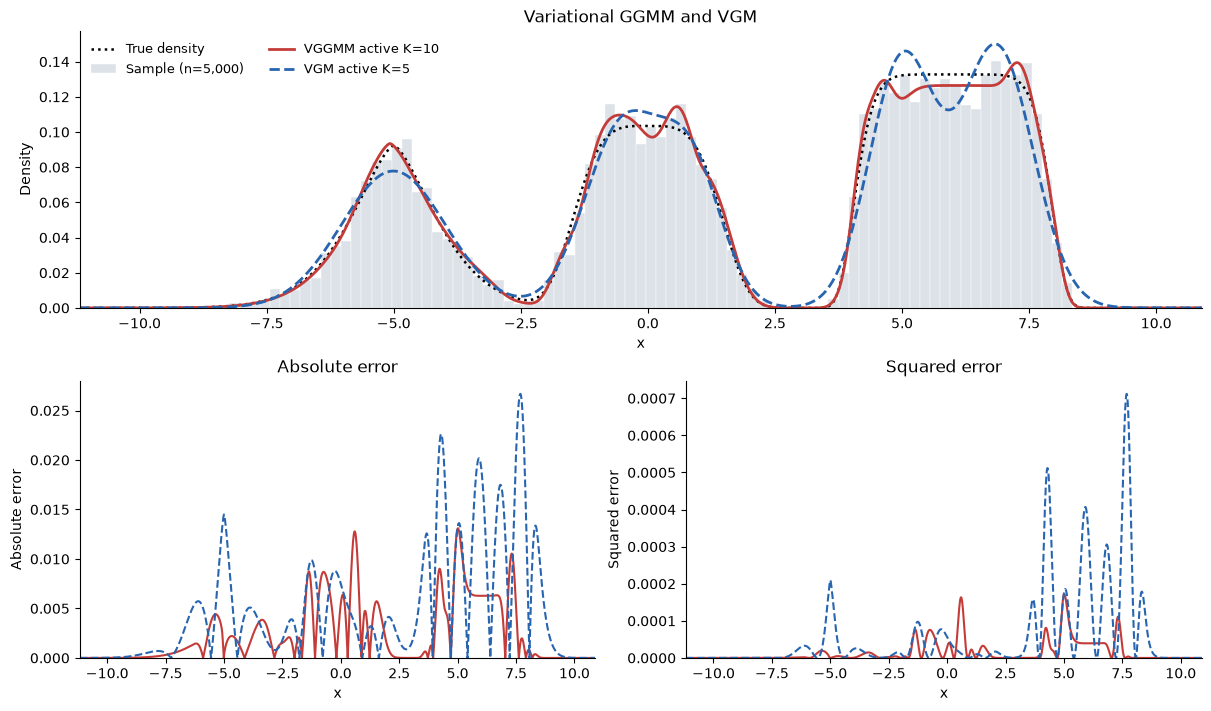

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.


In [5]:
# %% 실험 1: 추정식·파라미터·참 밀도 오차와 VGM 비교
# 이 셀은 한 그림에서 표본·참 밀도·GGMM·VGM 및 오차를 비교하고 같은 셀에 지표 표를 보여줍니다.
# VGM은 같은 X로 이 셀에서 새로 적합합니다. 같은 최대 성분 수와 같은 실제 K는 다릅니다.
overview_table = report_overview(result)


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,start,ELBO,converged,iterations,seconds,chosen,reason
0,quantile,-12357.7,True,140,95.1836,True,ELBO_gain_per_observation
1,lloyd,-12364.8,True,84,71.5955,False,ELBO_gain_per_observation


,start,component,weight,mu,a,b,chosen
0,quantile,1,0.10018,-5.78302,0.817703,1.63833,True
1,quantile,2,0.100158,-4.25381,0.948893,2.89069,True
2,quantile,3,0.100133,-1.05554,0.619311,2.55029,True
3,quantile,4,0.100104,-0.0336222,0.407243,2,True
4,quantile,5,0.100071,0.966973,2.80795,21.6224,True
5,quantile,6,0.100031,4.17399,0.172672,0.628594,True
6,quantile,7,0.0999807,5.18496,3.57846,42.1965,True
7,quantile,8,0.0999141,5.96814,2.35139,16.1065,True
8,quantile,9,0.0998143,6.78011,3.82771,58.4214,True
9,quantile,10,0.0996152,7.56452,0.473738,3.65227,True


두 시작점은 같은 상한을 가진 모델의 국소해 민감도를 확인합니다. K별 독립 적합이 아닙니다.
최종 ELBO로 시작점을 선택하며, IAE·ISE나 참 K는 사용하지 않습니다.


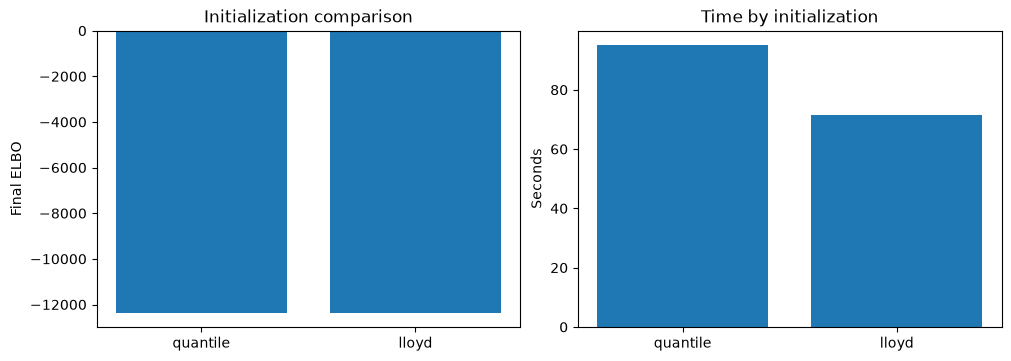

In [6]:
# %% 실험 2: 두 출발점 중 무엇이 채택되었는가?
# 이 셀은 실제 초기값·최종 ELBO·반복 수·수렴·시간을 보여줍니다. 재적합하지 않습니다.
# BIC에서 K마다 초기화를 비교했던 표를, 같은 상한에서의 두 초기화 비교로 바꿨습니다.
initialization_table = report_initialization(result)


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,iteration,elbo,log_likelihood,active_K,seconds
0,0,-17129.7,-13710.6,10,0.0415741
10,10,-12383.8,-12183.2,10,10.5223
20,20,-12375.7,-12177.2,10,18.0733
30,30,-12372.1,-12175.6,10,24.8194
40,40,-12369.6,-12174.5,10,31.6284
50,50,-12367.8,-12173.7,10,38.5764
60,60,-12366.9,-12173.3,10,45.2135
70,70,-12366.2,-12173,10,51.5796
80,80,-12365.3,-12172.8,10,57.7135
90,90,-12364.2,-12172.6,10,64.0677


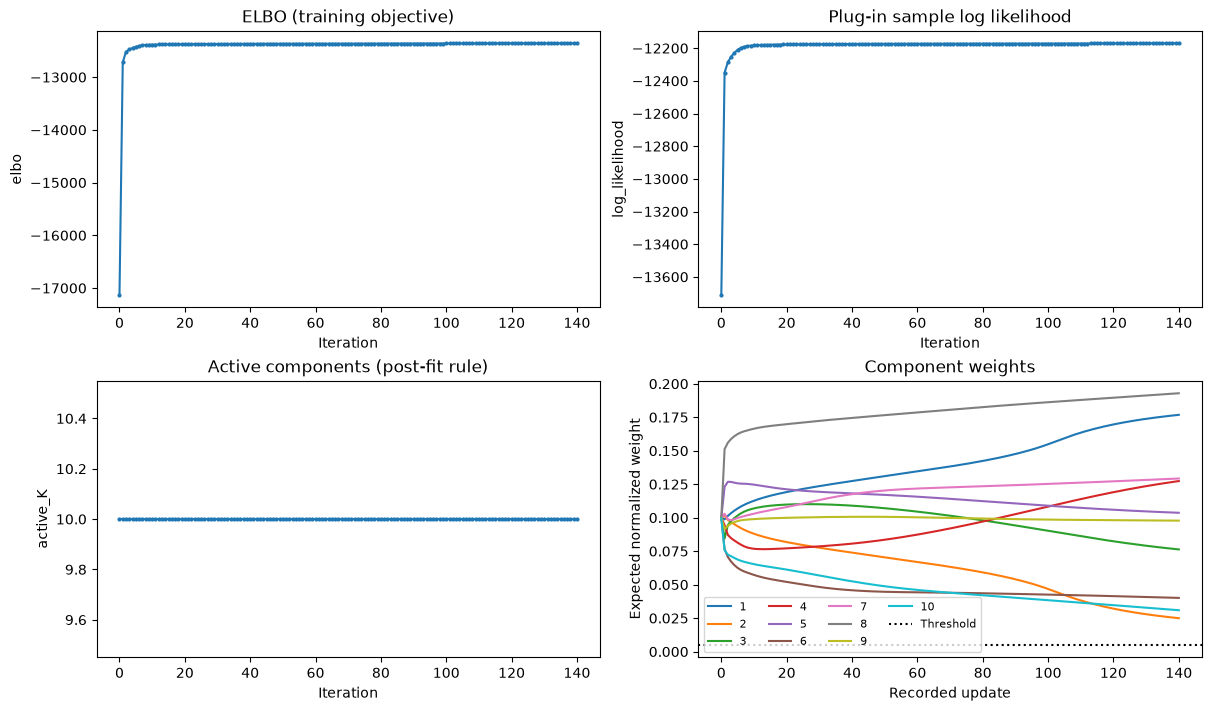

BIC 곡선 대신 학습 경로를 확인합니다.
ELBO와 plug-in LL은 다른 값입니다. LL 증가가 종료 기준이나 K 선택 기준은 아닙니다.
임계값은 학습 중 성분을 삭제하지 않습니다. active_K는 각 반복 가중치의 사후 집계입니다.
추정기 진단: {'requested_cap': 10, 'used_cap': 10, 'inactive_mass': 0.0, 'active_threshold': 0.005, 'active_fallback': False, 'cap_fully_active': True, 'last_stick_weight': 0.030902855831192098, 'min_a': 0.4365894011513581, 'max_b': 9.733985877845411, 'failed_starts': [], 'numerical_rejections': 0, 'inner_nonconverged': 1, 'optimizer_function_evaluations': 93296, 'initial_shape_fallbacks': 0, 'posterior_location_sd': [0.03303006075217958, 0.051716754227672385, 0.023579702161364898, 0.01828185189921016, 0.021003866983229588, 0.018254736516334476, 0.022353171902981354, 0.021484593440001202, 0.030808279744201347, 0.02332701113847212], 'gamma_shape': [596.2619980425588, 21.234562805230723, 86.45188542860521, 130.52734892585462, 205.1767032387439, 70.30955764671913, 106.8742864212664, 118.51051985229051, 51.34667485820903, 48.67439814712842], 'gamma_log_rate': [

In [7]:
# %% 실험 3: 학습하면서 유효 성분 수가 어떻게 바뀌는가?
# 이 셀은 ELBO·표본 LL·유효 K·각 가중치의 반복별 변화를 봅니다.
# 기존 K별 BIC 곡선 대신 실제 공동학습 경로를 확인합니다. 참 밀도는 이 경로에 관여하지 않습니다.
learning_table = report_learning(result)


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,stage,seconds
0,initialization_s,0.0476165
1,variational_s,5.63267
2,component_updates_s,161.098
3,other_s,0.0018634


,start,iterations,seconds,converged,chosen
0,quantile,140,95.1836,True,True
1,lloyd,84,71.5955,True,False


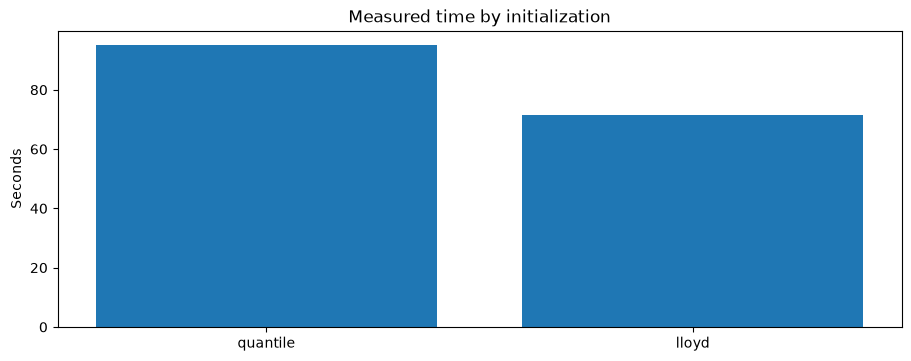

전체 fit() 실측: 166.899325초. 생성·평가·그림 시간은 제외합니다.
initialization_s·component_updates_s·variational_s·other_s는 중복 없는 구분입니다.
variational_s는 소속·가중치·ELBO 계산이며, 성분 파라미터 수치 갱신은 component_updates_s입니다.


In [8]:
# %% 실험 4: 적합시간은 어디에 사용되는가?
# 이 셀은 초기화·성분 수치 갱신·변분 갱신·그 밖의 시간과 시작점별 실측 시간을 보여줍니다.
# 시간은 현재 실행값이며 VGM보다 빠르다고 미리 가정하지 않습니다.
timing_table = report_timing(result)


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,Method,Fit_n,K,h,LL,Fit_s,LL_s,IAE,ISE,IAE_grid_change,ISE_grid_change,IAE_tail_upper
0,Variational GGMM active,5000,10,NaN,-12169.9,166.899,NaN,0.0538643,0.000338802,8.2824e-07,3.05196e-11,1.11022e-16
1,Gaussian KDE full,5000,5000,0.815305,-12660.9,0.0003237,0.841674,0.264094,0.00521025,7.50942e-07,1.25674e-09,4.44089e-15
2,Gaussian KDE n=3,3,3,3.08058,-14662.6,0.0002227,0.000543,0.759493,0.0360733,5.81513e-07,3.36182e-09,0


3개 KDE 추출 시드: 20260914 | 인덱스: [4522, 3243, 1038]
추출 관측값: [5.818552, 6.024767, -0.722823]
IAE·ISE: [-36.3574, 36.0724]의 16,001점 사다리꼴 근사; 8,001점과 차이도 공개합니다.
격자 차이는 엄밀한 오차 보장이 아닙니다. IAE_tail_upper는 구간 밖 오차의 상한입니다.
ISE는 유한 구간 값입니다. 적분 정밀도가 부족하면 격자를 늘려 확인하세요.
전체 X의 LL을 평가합니다. 3개 KDE는 전체 표본에 3성분을 최적화한 모델이 아닙니다.


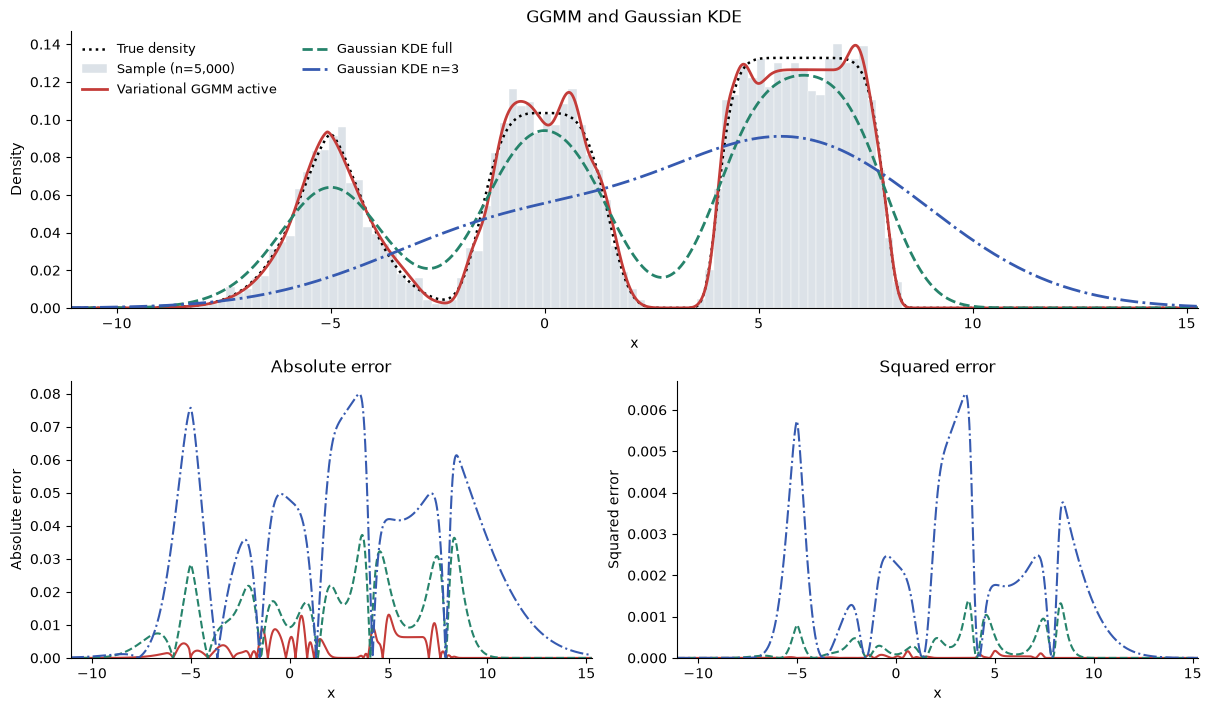

그림 표시 구간: [-11.0749, 15.2624]. 적분오차 평가는 그림과 별도로 계산합니다.


In [9]:
# %% 실험 5: GGMM과 전체 표본 KDE·3개 관측값 KDE 비교
# 이 셀은 같은 X에서 Gaussian KDE를 새로 계산하고 밀도·IAE·ISE·전체 X의 LL·시간을 보여줍니다.
# 3개 KDE는 같은 시드 20260914로 비복원 추출합니다. 전체 X의 최적 3성분 모형이 아닙니다.
# IAE·ISE는 공통 유한 격자 적분입니다. 격자 세분화 차이와 IAE 꼬리 오차 상한을 함께 공개합니다.
kde_table = report_kde(result)


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,threshold,removed_mass
0,threshold=0,10,-12169.9,0.0538642,0.000338802,NaN,0.120335,True,True,0,0
1,threshold=0.001,10,-12169.9,0.0538642,0.000338802,NaN,0.125143,True,True,0.001,0
2,threshold=0.005,10,-12169.9,0.0538642,0.000338802,NaN,0.113782,True,True,0.005,0
3,threshold=0.01,10,-12169.9,0.0538642,0.000338802,NaN,0.119304,True,True,0.01,0
4,threshold=0.02,10,-12169.9,0.0538642,0.000338802,NaN,0.120143,True,True,0.02,0


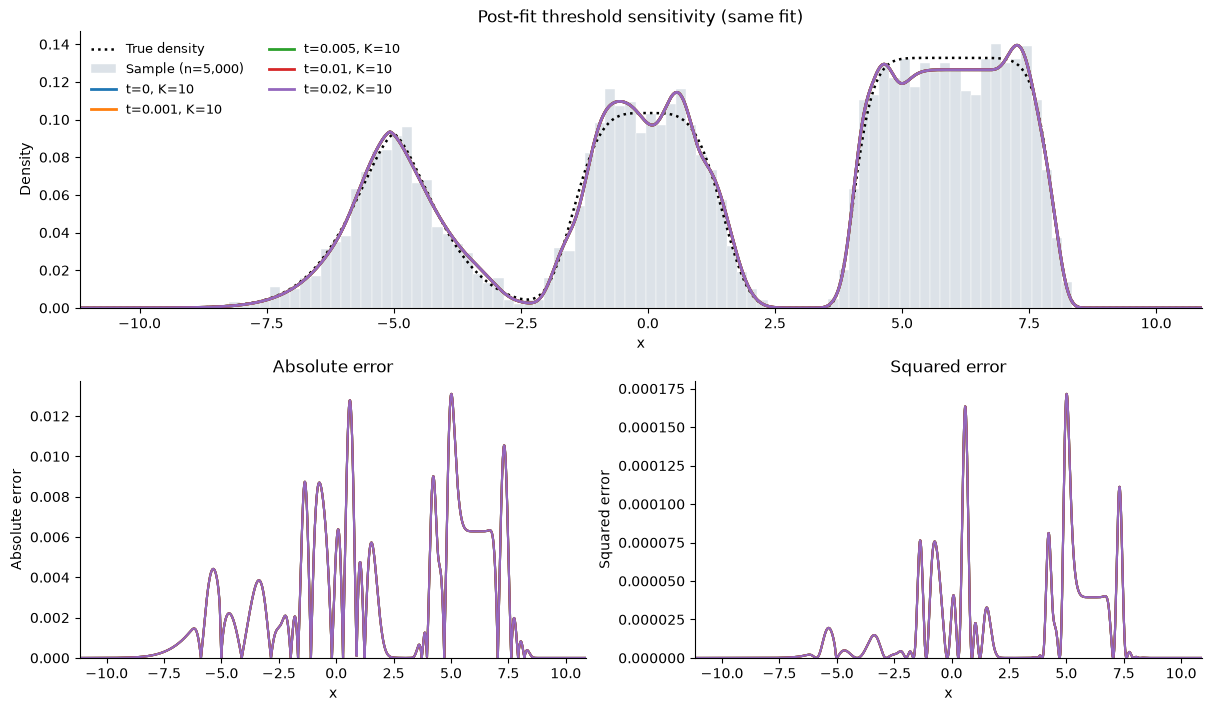

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.
재적합하지 않았습니다. 같은 학습 가중치를 다른 기준으로 잘라 재정규화한 진단입니다.
이 오차를 보고 최종 기준을 고르면 참 정보 사용이 됩니다. 기본 기준은 사전에 고정합니다.


In [10]:
# %% 실험 6: 유효 K가 임계값을 바꿔도 유지되는가?
# 이 셀은 같은 학습 결과에서 가중치 제외 기준만 바꿉니다. 재적합·사전분포 변경이 아닙니다.
# 성분을 제외한 질량과 재정규화 후의 밀도 변화를 확인합니다. 참 오차로 기준을 고르지 않습니다.
threshold_table = report_threshold(result, thresholds=(0., .001, .005, .01, .02))


Run: 2026-09-27T15:11:55.480615+00:00 | n=5,000 | cap=10 | active K=10
밀도·LL·IAE·ISE는 사후 파라미터를 대입한 밀도 기준입니다. 완전한 사후예측밀도가 아닙니다.


,component,weight,mu,a,b,sigma_derived,active
0,1,0.176787,-5.07412,1.16087,1.48356,1.00721,True
1,2,0.0249603,-4.36391,1.43656,6.12106,0.810064,True
2,3,0.0762926,-0.926818,0.975189,4.45546,0.560491,True
3,4,0.127341,-0.199042,1.02895,4.91264,0.586744,True
4,5,0.103661,0.990555,0.765848,2.53694,0.490321,True
5,6,0.0400996,4.41691,0.436589,2.88332,0.269331,True
6,7,0.129255,6.14818,1.41122,6.10791,0.795835,True
7,8,0.19291,6.01108,1.92509,8.22251,1.07962,True
8,9,0.0977909,5.94205,2.14356,9.73399,1.20191,True
9,10,0.0309029,7.6128,0.528305,3.25506,0.317187,True


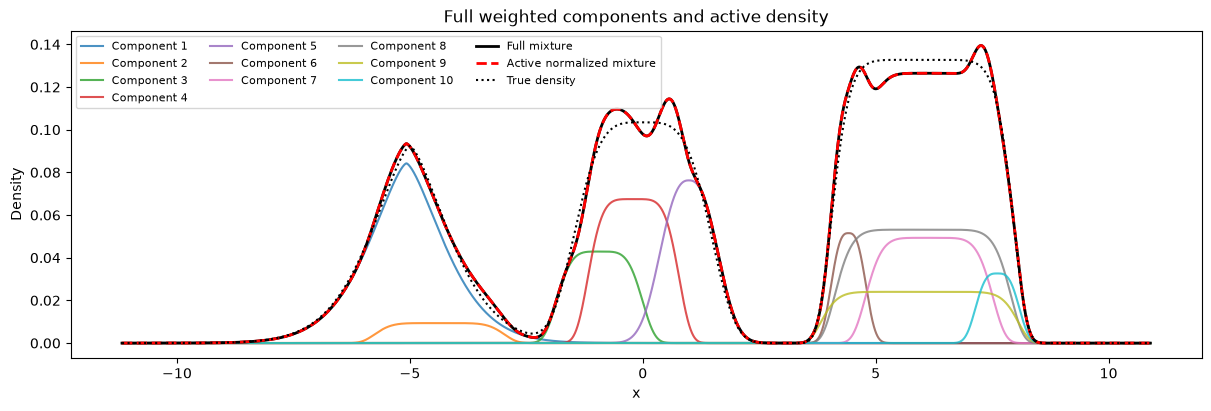

a는 척도이며 sigma_derived는 추정된 a,b에서 계산한 표준편차입니다. 별도 추정 변수가 아닙니다.
그림은 표본 범위에 양쪽 15% 여유를 둔 [-11.179, 10.8941] 구간입니다.


In [11]:
# %% 실험 7: 각 성분은 실제로 어디를 설명하는가?
# 이 셀은 제외되기 전 전체 성분의 가중치·mu·a·b와 가중 성분 밀도를 보여줍니다.
# 실제 유효 성분 수, 봉우리 수, 계산 중 보유한 성분 수를 구분하기 위한 실험입니다.
component_table = report_components(result)


새 변분 적합: cap=2
새 변분 적합: cap=10


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,concentration,precision_prior_rate,at_cap
0,cap=2,2,-12735.9,0.276437,0.00989943,2.09508,0.0533245,True,True,2,0.001,0.001,True
1,cap=10,10,-12169.9,0.0538642,0.000338802,168.669,0.116597,True,True,10,0.001,0.001,True


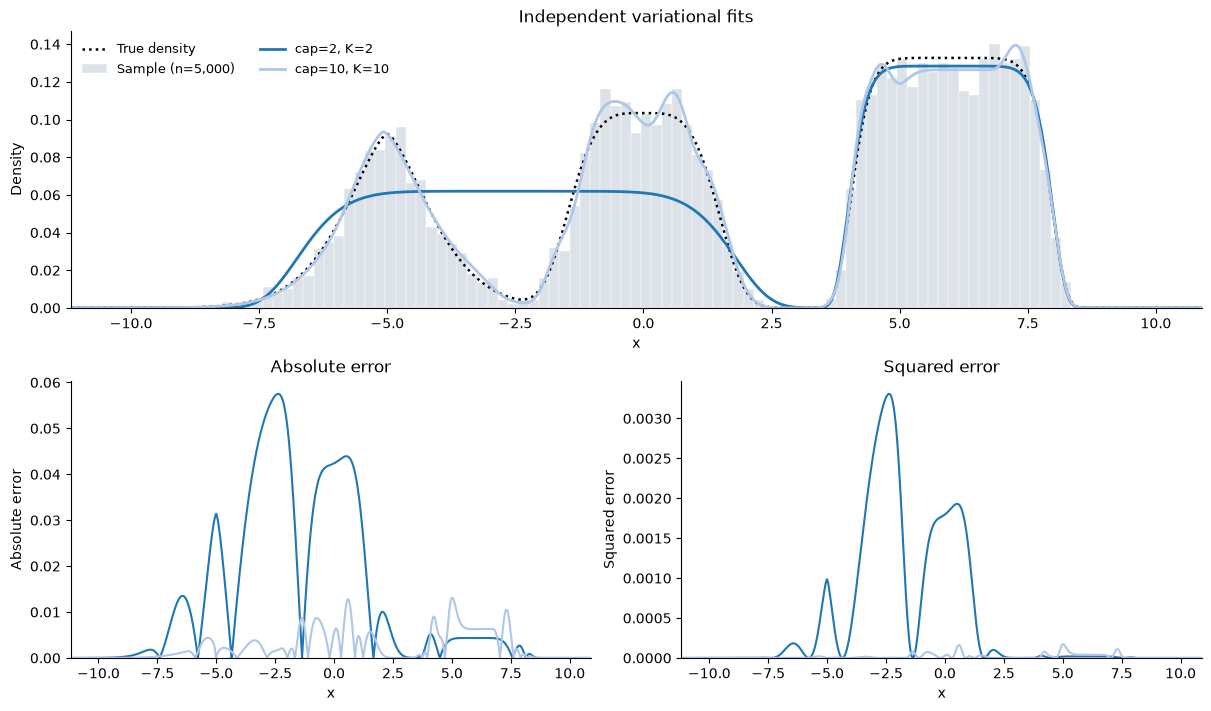

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.
각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.


In [17]:
# %% 선택 실험 8: 상한 2와 10에서 같은 표본을 각각 처음부터 적합
# 이 실험은 성분 상한이 부족한 경우를 확인합니다. 계산 부담 때문에 기본은 미실행입니다.
# 변분모형의 cap=10 결과를 잘라 cap=2 결과로 쓰면 안 됩니다. 두 모형은 서로 다른 공동학습입니다.
RUN_CAP_COMPARISON = True
if RUN_CAP_COMPARISON:
    cap_configs = [replace(VGGMMConfig(**result['config']), max_components=k) for k in (2, 10)]
    cap_runs, cap_table = compare_settings(result, cap_configs, ['cap=2', 'cap=10'])
    runs.update({run['run_id']: run for run in cap_runs})
else:
    print('미실행: 상한 제한 실험은 RUN_CAP_COMPARISON=True로 실행하세요.')


새 비교: 같은 상한 3
새 비교: 같은 상한 5


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,same_actual_K,plugin_parameters
0,VGGMM,3,-12177.4,0.0289682,9.12505e-05,35.1122,0.043782,True,True,3,True,11
1,VGM,3,-12460.5,0.213372,0.0051654,0.0093859,0.0601887,True,True,3,True,8
2,VGGMM,4,-12175.8,0.0361014,0.000191764,98.7349,0.0551268,True,True,5,True,15
3,VGM,4,-12302.4,0.13997,0.00192153,0.304176,0.0745103,True,True,5,True,11


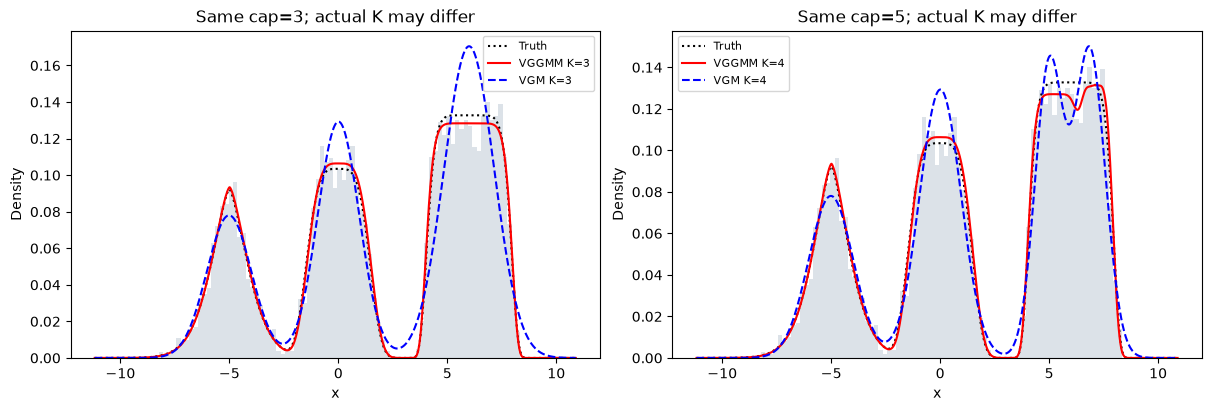

실제 K가 일치한 행만 같은 K 비교입니다. 사후에 K를 맞추려고 threshold를 조정하지 않습니다.
plugin_parameters는 출력 밀도의 자유 파라미터 수이며, 변분분포의 파라미터 개수는 아닙니다.
그림은 표본 범위에 양쪽 15% 여유를 둔 구간입니다. 적분오차는 별도로 계산합니다.


In [18]:
# %% 선택 실험 9: 3·5 상한에서 GGMM과 VGM의 실제 유효 K를 함께 확인
# 이 실험은 같은 상한을 주고 독립 적합합니다. 실제 K가 다른데 3vs3·5vs5로 부르지 않습니다.
# same_actual_K=True인 조건만 실제 성분 수가 같은 비교로 보고할 수 있습니다.
RUN_SAME_CAP_COMPARISON = True
if RUN_SAME_CAP_COMPARISON:
    same_cap_runs, same_cap_table = compare_same_cap(result, caps=(3, 5))
    runs.update({run['run_id']: run for run in same_cap_runs})
else:
    print('미실행: 동일 상한 비교는 RUN_SAME_CAP_COMPARISON=True로 실행하세요.')


새 변분 적합: Fixed b=2
새 변분 적합: Estimated b


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,concentration,precision_prior_rate,at_cap
0,Fixed b=2,10,-12177.9,0.056663,0.000481783,25.6677,0.107081,True,True,10,0.001,0.001,True
1,Estimated b,10,-12169.9,0.0538642,0.000338802,164.022,0.125514,True,True,10,0.001,0.001,True


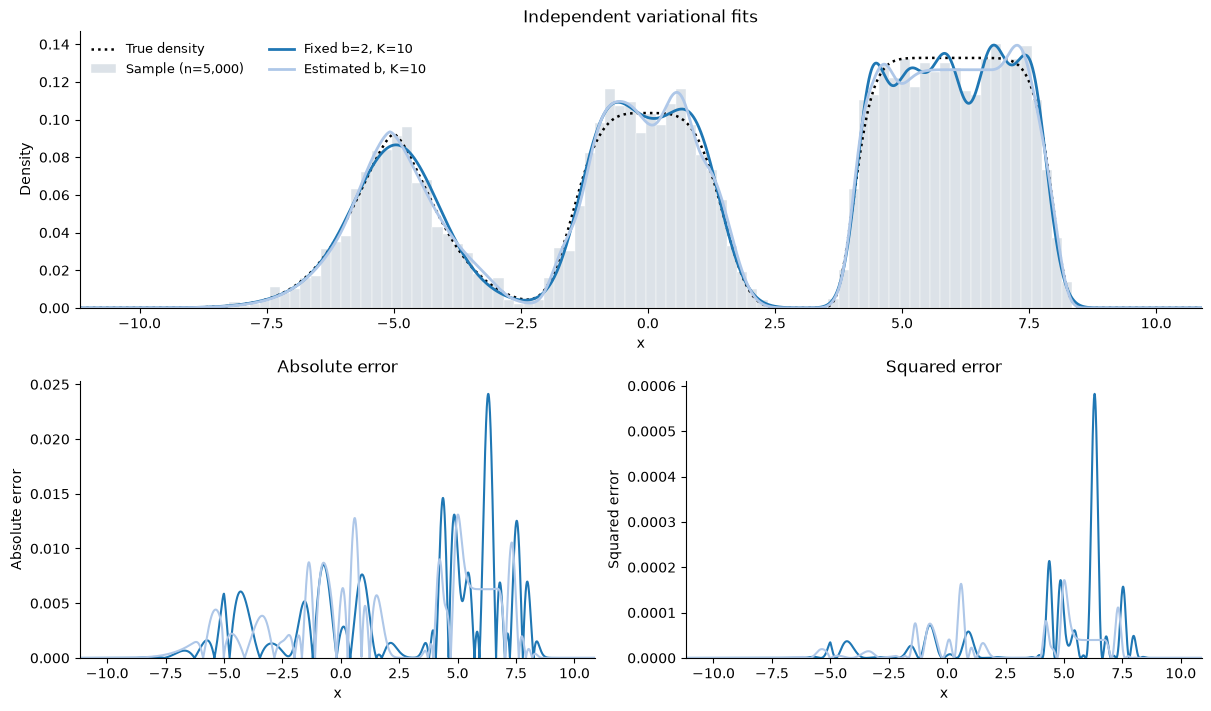

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.
각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.


In [19]:
# %% 선택 실험 10: 형상 추정의 효과를 같은 변분 구현 안에서 분리
# 이 실험은 가우시안 특수 경우 b=2 고정과 성분별 b 추정을 같은 설정·X·초기화로 비교합니다.
# sklearn VGM과의 차이에는 추론·사전 설정도 섞이므로, 이 비교가 형상 추가 효과를 확인하는 데 유용합니다.
RUN_SHAPE_ABLATION = True
if RUN_SHAPE_ABLATION:
    base_config = VGGMMConfig(**result['config'])
    shape_runs, shape_table = compare_settings(result,
        [replace(base_config, fixed_shape=2.), replace(base_config, fixed_shape=None)],
        ['Fixed b=2', 'Estimated b'])
    runs.update({run['run_id']: run for run in shape_runs})
else:
    print('미실행: 형상 비교는 RUN_SHAPE_ABLATION=True로 실행하세요.')


새 변분 적합: concentration=0.0001
새 변분 적합: concentration=0.001
새 변분 적합: concentration=0.01


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,concentration,precision_prior_rate,at_cap
0,concentration=0.0001,10,-12169.9,0.0538816,0.000338915,166.79,0.115149,True,True,10,0.0001,0.001,True
1,concentration=0.001,10,-12169.9,0.0538642,0.000338802,167.623,0.127583,True,True,10,0.001,0.001,True
2,concentration=0.01,10,-12169.9,0.0538803,0.000339028,167.13,0.112221,True,True,10,0.01,0.001,True


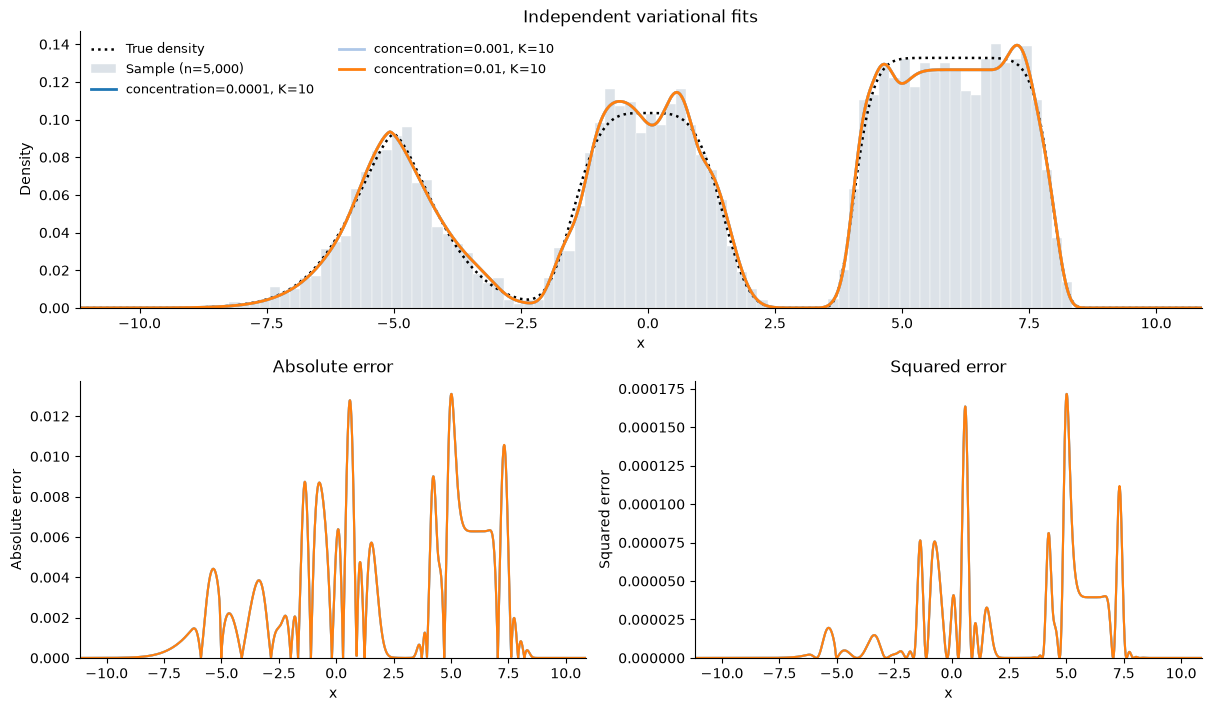

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.
각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.
새 변분 적합: precision prior rate=0.0001
새 변분 적합: precision prior rate=0.001
새 변분 적합: precision prior rate=0.01


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,concentration,precision_prior_rate,at_cap
0,precision prior rate=0.0001,10,-12167.2,0.0508101,0.000313813,196.807,0.113256,True,True,10,0.001,0.0001,True
1,precision prior rate=0.001,10,-12169.9,0.0538642,0.000338802,169.172,0.122923,True,True,10,0.001,0.001,True
2,precision prior rate=0.01,10,-12175.1,0.0557902,0.000376949,72.5251,0.109208,True,True,10,0.001,0.01,True


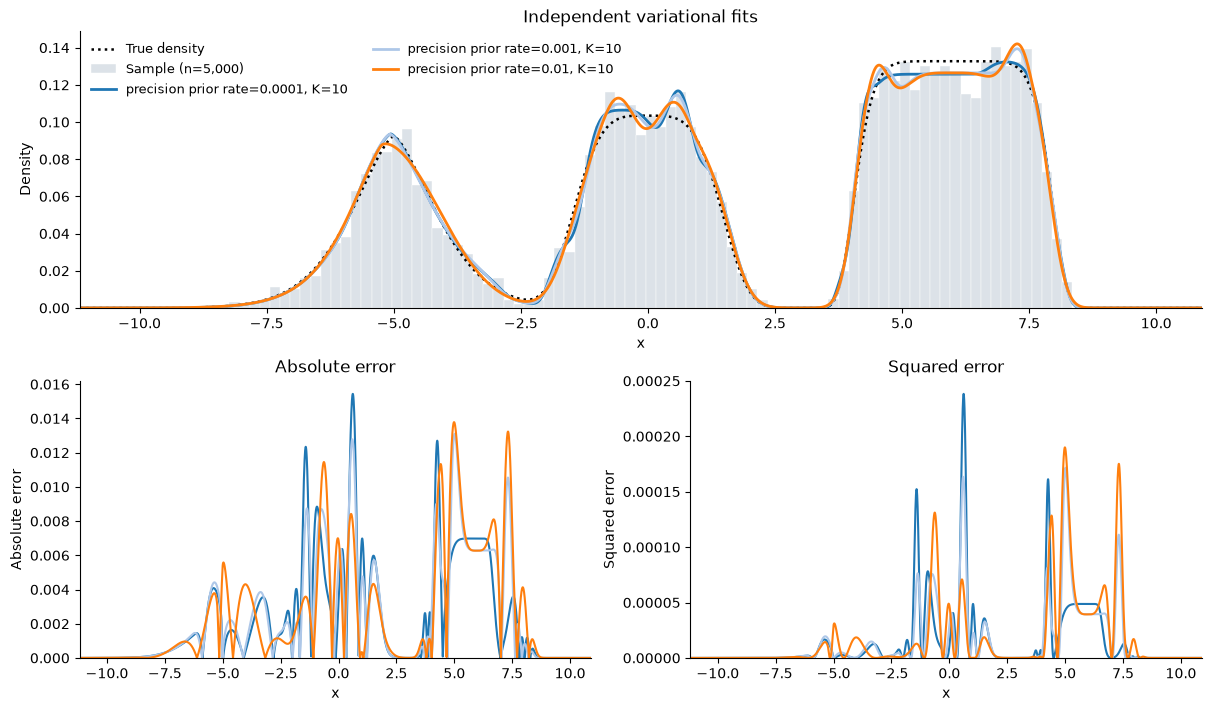

그림 표시 구간: [-11.179, 10.8941]. 적분오차 평가는 그림과 별도로 계산합니다.
각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.


In [20]:
# %% 선택 실험 11: 성분 수와 폭에 영향을 주는 사전분포 민감도
# 이 실험은 이전 척도 하한 비교를 대체합니다. 하한=0 비교가 아니라 사전분포 조건 변경입니다.
# 한 번에 하나만 바꿉니다. DP concentration과 Gamma precision prior rate의 영향을 분리합니다.
RUN_PRIOR_SENSITIVITY = True
if RUN_PRIOR_SENSITIVITY:
    base_config = VGGMMConfig(**result['config'])
    prior_configs = [replace(base_config, concentration=c) for c in (.0001, .001, .01)]
    prior_labels = [f'concentration={c:g}' for c in (.0001, .001, .01)]
    prior_runs, prior_table = compare_settings(result, prior_configs, prior_labels)
    runs.update({run['run_id']: run for run in prior_runs})
    rate_values = [base_config.precision_prior_rate/10, base_config.precision_prior_rate,
                   base_config.precision_prior_rate*10]
    rate_runs, rate_table = compare_settings(result,
        [replace(base_config, precision_prior_rate=r) for r in rate_values],
        [f'precision prior rate={r:g}' for r in rate_values])
    runs.update({run['run_id']: run for run in rate_runs})
else:
    print('미실행: 사전분포 비교는 RUN_PRIOR_SENSITIVITY=True로 실행하세요.')


새 변분 적합: cap=6
새 변분 적합: cap=7
새 변분 적합: cap=8
새 변분 적합: cap=9
새 변분 적합: cap=10
새 변분 적합: cap=11
새 변분 적합: cap=12
새 변분 적합: cap=13


C:\Users\user\AppData\Local\Temp\ipykernel_35264\1628055476.py:430: RuntimeWarning: 1 variational initialization(s) failed; see diagnostics_.
  if failed: warnings.warn(f'{len(failed)} variational initialization(s) failed; see diagnostics_.',RuntimeWarning)


새 변분 적합: cap=14
새 변분 적합: cap=15
각 설정은 같은 X에서 처음부터 새로 적합했습니다. 기본 result는 바꾸지 않았습니다.


,Method,K,LL,IAE,ISE,Fit_s,Evaluation_s,Converged,Integral_OK,cap,at_cap,concentration,precision_prior_rate
0,cap=5,5,-17874.8,0.475695,0.00791573,11.6507,0.173766,True,False,5,True,NaN,NaN
1,cap=6,6,-17765.1,0.381122,0.00681483,25.0063,0.181734,True,True,6,True,0.001,0.001
2,cap=7,7,-17488,0.319398,0.00518001,28.7747,0.201973,True,False,7,True,0.001,0.001
3,cap=8,8,-17276.3,0.190834,0.00239262,24.4369,0.214311,True,True,8,True,0.001,0.001
4,cap=9,9,-17276.1,0.190894,0.00239438,45.0294,0.233129,True,True,9,True,0.001,0.001
5,cap=10,10,-16948.8,0.0740804,0.000312125,73.1691,0.259508,True,True,10,True,0.001,0.001
6,cap=11,11,-16948.6,0.0747284,0.000316047,66.318,0.259733,True,True,11,True,0.001,0.001
7,cap=12,12,-16942.5,0.0744478,0.000312379,69.0288,0.290761,True,True,12,True,0.001,0.001
8,cap=13,13,-16947.8,0.078805,0.000339355,103.098,0.308388,True,True,13,True,0.001,0.001
9,cap=14,13,-16942.9,0.0735661,0.000311527,159.487,0.292521,True,True,14,False,0.001,0.001


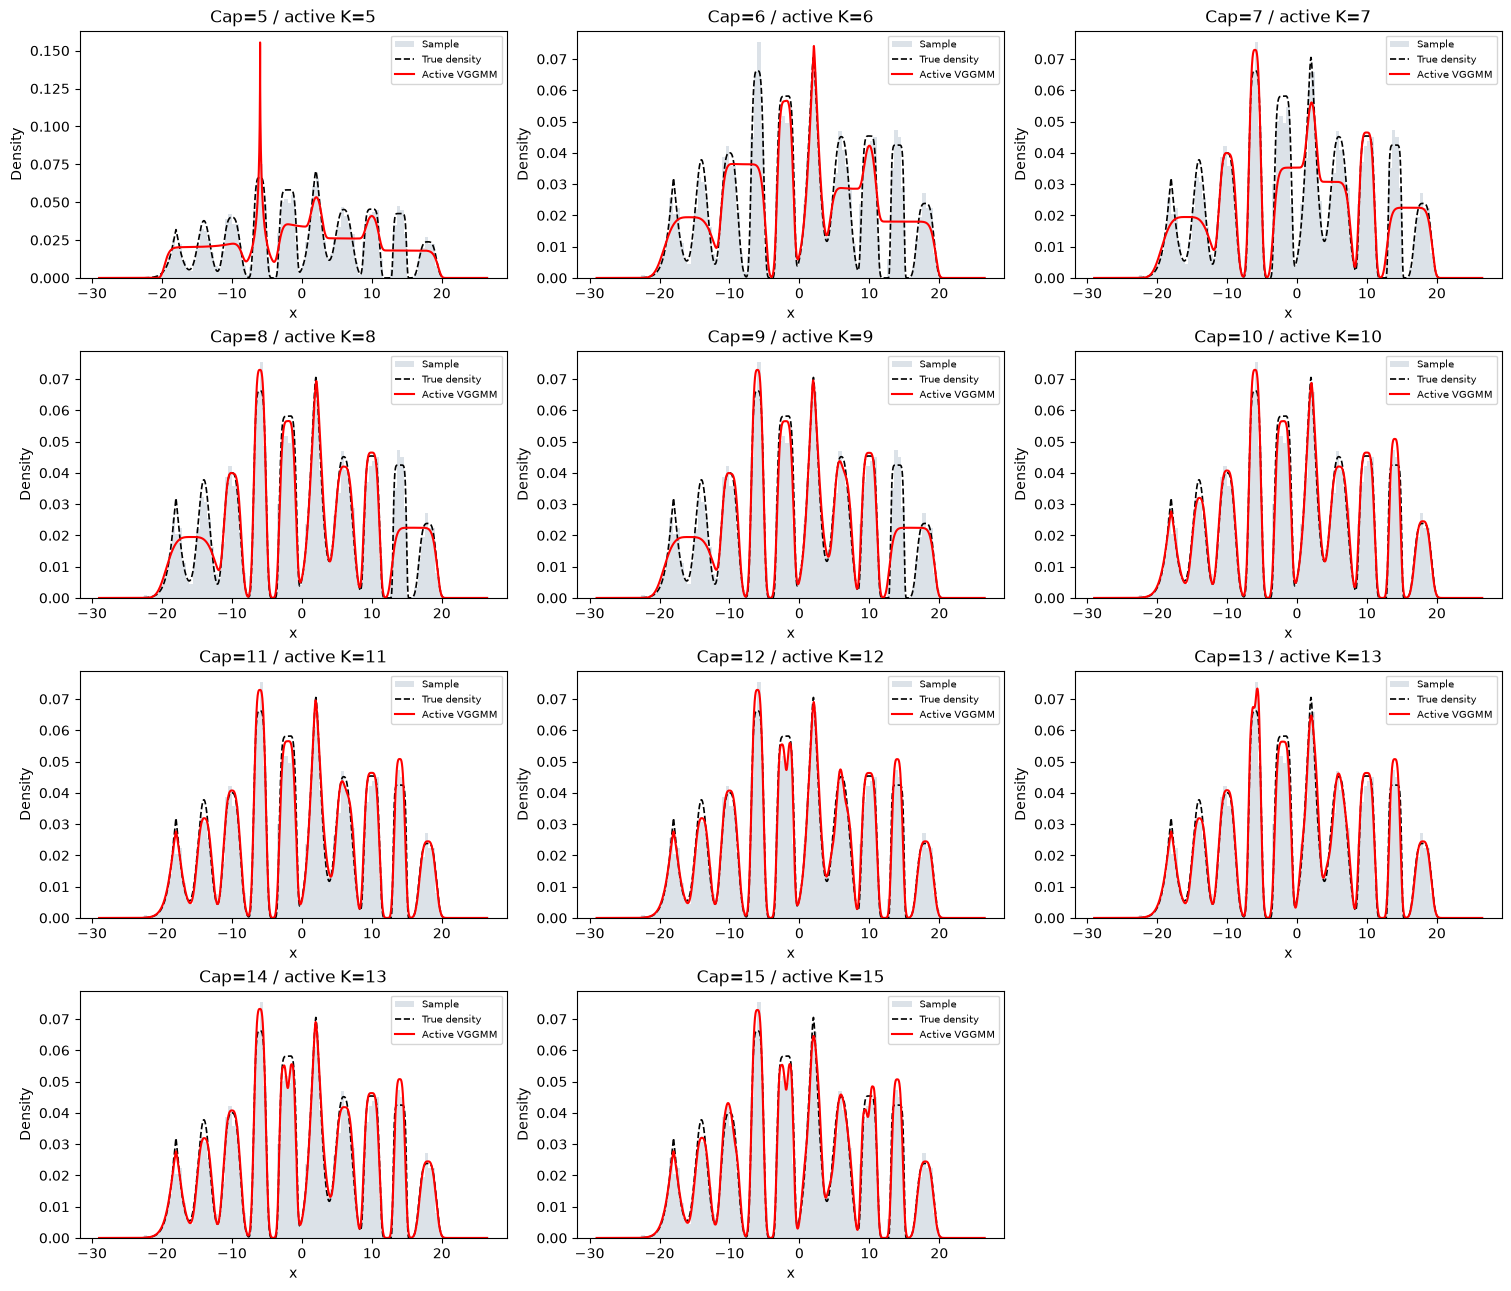

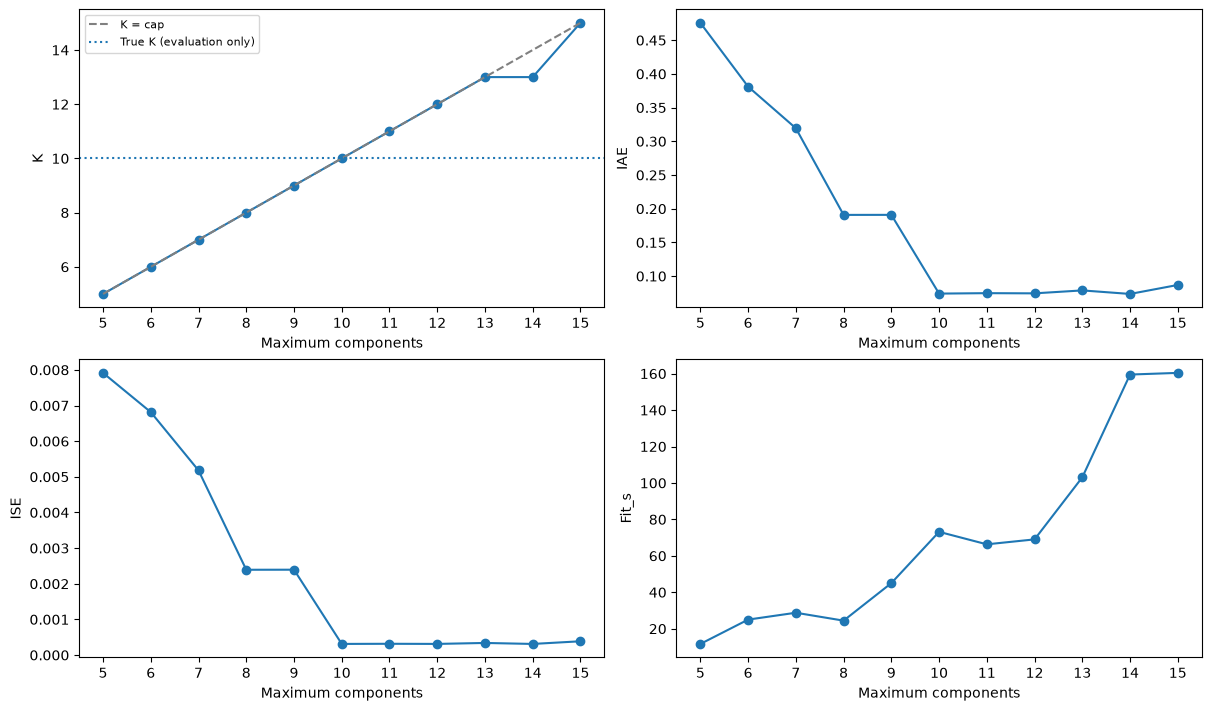

각 조건은 독립 재적합입니다. 그림은 각 표본 범위에 양쪽 15% 여유를 둔 구간입니다.


In [21]:
# %% 선택 실험 12: 참 K=10 표본에서 상한 5~15의 결과가 어떻게 바뀌는가?
# 이 실험은 이전 참 K=10 실험과 같은 분포·n=5000·seed=20260919를 씁니다.
# 참 K는 생성에만 쓰며 추정기에 넘기지 않습니다. 상한마다 새로 적합하므로 시간이 많이 듭니다.
# K=1~15 후보를 한 번 적합해 범위를 잘랐던 BIC 코드와 달리, 변분모형은 상한마다 다시 학습합니다.
RUN_TRUE10_CAPS = True
if RUN_TRUE10_CAPS:
    truth10 = Mixture(weights=[.06, .08, .10, .12, .14, .14, .12, .10, .08, .06],
        means=[-18, -14, -10, -6, -2, 2, 6, 10, 14, 18],
        scales=[1., 1.2, 1.4, 1., 1.3, 1.1, 1.5, 1.2, 1., 1.4],
        shapes=[1.2, 2., 3., 4., 6., 1.5, 2.5, 5., 8., 3.5])
    X10 = sample_mixture(truth10, 5000, 20260919)
    config10 = replace(VGGMMConfig(**result['config']), max_components=5)
    # 첫 조건의 실제 적합 결과를 다음 비교의 기준 컨테이너로 사용합니다.
    first10 = run_variational_experiment(X10, config=config10, truth=truth10, sample_seed=20260919)
    configs10 = [replace(config10, max_components=k) for k in range(6, 16)]
    rest10, rest10_table = compare_settings(first10, configs10, [f'cap={k}' for k in range(6, 16)], show=False)
    true10_runs = [first10, *rest10]
    first_row = mixture_row(first10, 'cap=5', first10['ggmm'].density_,
                            first10['fit_seconds'], first10['ggmm'].converged_)
    first_row.update(cap=5, at_cap=first10['ggmm'].n_components_ == 5)
    true10_table = pd.concat([pd.DataFrame([first_row]), rest10_table], ignore_index=True)
    show_cap_sweep(true10_runs, true10_table)
    runs.update({run['run_id']: run for run in true10_runs})
else:
    print('미실행: 참 K=10 상한 실험은 RUN_TRUE10_CAPS=True로 실행하세요.')
